In [4]:
%pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import joblib
import os
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import cv2

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"{'='*70}")
print(f"🔧 SYSTEM CONFIGURATION")
print(f"{'='*70}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"CUDA Version: {torch.version.cuda}")

# Paths (FIXED)
BASE_OUT = "../data/processed"
IMG_DIR = "../images/train"  # ✅ Correct path
SAVE_DIR = "../output"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"\n{'='*70}")
print(f"📁 DATA PATHS")
print(f"{'='*70}")
print(f"Preprocessed data: {BASE_OUT}")
print(f"Images directory: {IMG_DIR}")
print(f"Output directory: {SAVE_DIR}")

# Verify image directory exists
if os.path.exists(IMG_DIR):
    image_files = [f for f in os.listdir(IMG_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))]
    print(f"\n✅ Image directory verified!")
    print(f"   Total images found: {len(image_files)}")
    print(f"   Sample files: {image_files[:3]}")
else:
    print(f"\n❌ ERROR: Image directory not found at {IMG_DIR}")
    print(f"   Please verify the path!")

print("\n✅ Setup complete!")

C:\Users\keshav bansal\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔧 SYSTEM CONFIGURATION
Device: cpu

📁 DATA PATHS
Preprocessed data: ../data/processed
Images directory: ../images/train
Output directory: ../output

✅ Image directory verified!
   Total images found: 16201
   Sample files: ['0.png', '1.png', '10.png']

✅ Setup complete!


In [5]:
# ============================================================================
# CELL 2: LOAD PREPROCESSED DATA
# ============================================================================

print(f"{'='*70}")
print("📊 LOADING PREPROCESSED DATA")
print(f"{'='*70}")

X = np.load(f"{BASE_OUT}/X_scaled.npy")
y = np.load(f"{BASE_OUT}/y.npy")  # Already log-transformed
ids = np.load(f"{BASE_OUT}/ids.npy")
train_idx = np.load(f"{BASE_OUT}/train_idx.npy")
val_idx = np.load(f"{BASE_OUT}/val_idx.npy")

# Load feature names and scaler
feature_cols = joblib.load(f"{BASE_OUT}/feature_cols.pkl")
scaler = joblib.load(f"{BASE_OUT}/scaler.pkl")

X_train, X_val = X[train_idx], X[val_idx]
y_train, y_val = y[train_idx], y[val_idx]
ids_train, ids_val = ids[train_idx], ids[val_idx]

print(f"\n📈 Dataset Summary:")
print(f"{'─'*70}")
print(f"Total samples: {len(X):,}")
print(f"Training samples: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation samples: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Number of features: {X_train.shape[1]}")

print(f"\n📊 Target Statistics (log scale):")
print(f"{'─'*70}")
print(f"Train - Mean: {y_train.mean():.4f}, Std: {y_train.std():.4f}")
print(f"       Min: {y_train.min():.4f}, Max: {y_train.max():.4f}")
print(f"Val   - Mean: {y_val.mean():.4f}, Std: {y_val.std():.4f}")
print(f"       Min: {y_val.min():.4f}, Max: {y_val.max():.4f}")

print(f"\n💰 Target Statistics (Original Scale in $):")
print(f"{'─'*70}")
train_prices = np.expm1(y_train)
val_prices = np.expm1(y_val)
print(f"Train - Mean: ${train_prices.mean():,.0f}, Median: ${np.median(train_prices):,.0f}")
print(f"       Min: ${train_prices.min():,.0f}, Max: ${train_prices.max():,.0f}")
print(f"Val   - Mean: ${val_prices.mean():,.0f}, Median: ${np.median(val_prices):,.0f}")
print(f"       Min: ${val_prices.min():,.0f}, Max: ${val_prices.max():,.0f}")

print(f"\n📝 Feature Names ({len(feature_cols)} features):")
print(f"{'─'*70}")
print(f"{feature_cols}")

print("\n✅ Data loaded successfully!")

📊 LOADING PREPROCESSED DATA

📈 Dataset Summary:
──────────────────────────────────────────────────────────────────────
Total samples: 16,209
Training samples: 12,967 (80.0%)
Validation samples: 3,242 (20.0%)
Number of features: 24

📊 Target Statistics (log scale):
──────────────────────────────────────────────────────────────────────
Train - Mean: 13.0440, Std: 0.5235
       Min: 11.2898, Max: 15.8567
Val   - Mean: 13.0502, Std: 0.5253
       Min: 11.2253, Max: 15.4469

💰 Target Statistics (Original Scale in $):
──────────────────────────────────────────────────────────────────────
Train - Mean: $536,804, Median: $450,000
       Min: $80,000, Max: $7,700,000
Val   - Mean: $540,135, Median: $452,000
       Min: $75,000, Max: $5,110,800

📝 Feature Names (24 features):
──────────────────────────────────────────────────────────────────────
['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'long',

In [6]:

print(f"{'='*70}")
print("🔧 FIXING FEATURE SET - REMOVING TARGET VARIABLE")
print(f"{'='*70}")

if 'log_price' in feature_cols:
    print(f"\n WARNING: 'log_price' found in features - REMOVING IT!")
    
    # Find the index of log_price
    log_price_idx = feature_cols.index('log_price')
    
    print(f"   Position in feature list: {log_price_idx}")
    print(f"   Original feature count: {len(feature_cols)}")
    
    feature_cols.remove('log_price')
    
    X = np.delete(X, log_price_idx, axis=1)
    X_train = np.delete(X_train, log_price_idx, axis=1)
    X_val = np.delete(X_val, log_price_idx, axis=1)
    
    print(f"   New feature count: {len(feature_cols)}")
    print(f"   New X shape: {X.shape}")
    print(f"   New X_train shape: {X_train.shape}")
    print(f"   New X_val shape: {X_val.shape}")
    
    print(f"\n✅ log_price successfully removed from features!")
else:
    print(f"\n✅ log_price not in features - data is clean!")

print(f"\n📝 Final Feature List ({len(feature_cols)} features):")
print(f"{'─'*70}")
for i, feat in enumerate(feature_cols, 1):
    print(f"   {i:2d}. {feat}")

print(f"\n✅ Feature set corrected!")

🔧 FIXING FEATURE SET - REMOVING TARGET VARIABLE

   Position in feature list: 17
   Original feature count: 24
   New feature count: 23
   New X shape: (16209, 23)
   New X_train shape: (12967, 23)
   New X_val shape: (3242, 23)

✅ log_price successfully removed from features!

📝 Final Feature List (23 features):
──────────────────────────────────────────────────────────────────────
    1. bedrooms
    2. bathrooms
    3. sqft_living
    4. sqft_lot
    5. floors
    6. waterfront
    7. view
    8. condition
    9. grade
   10. sqft_above
   11. sqft_basement
   12. lat
   13. long
   14. sqft_living15
   15. sqft_lot15
   16. lat_bin
   17. long_bin
   18. house_age
   19. basement_ratio
   20. bath_bed_ratio
   21. land_utilization
   22. quality_score
   23. view_waterfront

✅ Feature set corrected!


In [7]:


def evaluate_model(y_true, y_pred, model_name="Model", log_scale=True, show_plot=True):
    """
    Comprehensive evaluation with log and original scale metrics
    
    Args:
        y_true: True values (log scale)
        y_pred: Predicted values (log scale)
        model_name: Model name for display
        log_scale: Whether to compute original scale metrics
        show_plot: Whether to show plots
    """
    print(f"\n{'='*70}")
    print(f"📊 {model_name} - EVALUATION RESULTS")
    print(f"{'='*70}")
    
    # Log scale metrics
    rmse_log = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_log = mean_absolute_error(y_true, y_pred)
    r2_log = r2_score(y_true, y_pred)
    
    print(f"\n📈 Log Scale Metrics:")
    print(f"{'─'*70}")
    print(f"   RMSE (log): {rmse_log:.6f}")
    print(f"   MAE (log):  {mae_log:.6f}")
    print(f"   R² Score:   {r2_log:.6f}")
    
    metrics = {
        'rmse_log': rmse_log,
        'mae_log': mae_log,
        'r2_log': r2_log
    }
    
    if log_scale:
        
        y_true_orig = np.expm1(y_true)
        y_pred_orig = np.expm1(y_pred)
        
        rmse_orig = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
        mae_orig = mean_absolute_error(y_true_orig, y_pred_orig)
        r2_orig = r2_score(y_true_orig, y_pred_orig)
        mape = np.mean(np.abs((y_true_orig - y_pred_orig) / y_true_orig)) * 100
        
        print(f"\n💰 Original Scale Metrics ($):")
        print(f"{'─'*70}")
        print(f"   RMSE:       ${rmse_orig:,.0f}")
        print(f"   MAE:        ${mae_orig:,.0f}")
        print(f"   R² Score:   {r2_orig:.6f}")
        print(f"   MAPE:       {mape:.2f}%")
        
        # Prediction quality analysis
        errors = y_pred_orig - y_true_orig
        abs_errors = np.abs(errors)
        pct_errors = np.abs(errors / y_true_orig) * 100
        
        print(f"\n🎯 Prediction Quality Analysis:")
        print(f"{'─'*70}")
        print(f"   Mean Error:           ${errors.mean():,.0f}")
        print(f"   Median Abs Error:     ${np.median(abs_errors):,.0f}")
        print(f"   Error Std Dev:        ${errors.std():,.0f}")
        print(f"   Within ±5%:           {(pct_errors <= 5).mean()*100:.1f}%")
        print(f"   Within ±10%:          {(pct_errors <= 10).mean()*100:.1f}%")
        print(f"   Within ±20%:          {(pct_errors <= 20).mean()*100:.1f}%")
        
        metrics.update({
            'rmse': rmse_orig,
            'mae': mae_orig,
            'r2': r2_orig,
            'mape': mape
        })
        
        if show_plot:
            plot_predictions(y_true, y_pred, title=f"{model_name} - Performance", log_scale=True)
    
    return metrics

def plot_predictions(y_true, y_pred, title="Predictions vs Actual", log_scale=True):
    """Enhanced prediction visualization"""
    if log_scale:
        y_true_plot = np.expm1(y_true)
        y_pred_plot = np.expm1(y_pred)
    else:
        y_true_plot = y_true
        y_pred_plot = y_pred
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    
    # 1. Scatter plot
    axes[0].scatter(y_true_plot, y_pred_plot, alpha=0.4, s=15, color='#3498db')
    axes[0].plot([y_true_plot.min(), y_true_plot.max()], 
                 [y_true_plot.min(), y_true_plot.max()], 
                 'r--', lw=2.5, label='Perfect Prediction', alpha=0.8)
    
    r2 = r2_score(y_true_plot, y_pred_plot)
    axes[0].set_xlabel('Actual Price ($)', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Predicted Price ($)', fontsize=13, fontweight='bold')
    axes[0].set_title(f'{title}\nR² = {r2:.6f}', fontsize=15, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)
    
    # 2. Residual plot
    residuals = y_pred_plot - y_true_plot
    axes[1].scatter(y_pred_plot, residuals, alpha=0.4, s=15, color='#e74c3c')
    axes[1].axhline(y=0, color='black', linestyle='--', lw=2.5, alpha=0.8)
    axes[1].set_xlabel('Predicted Price ($)', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Residuals ($)', fontsize=13, fontweight='bold')
    axes[1].set_title('Residual Plot', fontsize=15, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    pct_errors = (residuals / y_true_plot) * 100
    axes[2].hist(pct_errors, bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[2].axvline(x=0, color='red', linestyle='--', lw=2.5, label='Zero Error')
    axes[2].set_xlabel('Percentage Error (%)', fontsize=13, fontweight='bold')
    axes[2].set_ylabel('Frequency', fontsize=13, fontweight='bold')
    axes[2].set_title('Error Distribution', fontsize=15, fontweight='bold')
    axes[2].legend(fontsize=11)
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("✅ Evaluation functions defined!")

✅ Evaluation functions defined!


In [8]:
import os

print(f"{'='*30} DEBUGGING PATHS {'='*30}")

# 1. Check where Python thinks it is running
print(f"Current Working Directory: {os.getcwd()}")

# 2. Check what IMG_DIR is set to
print(f"Value of IMG_DIR: {IMG_DIR}")

# 3. Check what is actually inside IMG_DIR
if os.path.exists(IMG_DIR):
    contents = os.listdir(IMG_DIR)[:5] # Show first 5 files
    print(f"First 5 items in IMG_DIR: {contents}")
    
    if "train" in contents:
        print("\n⚠️ WARNING: I see a 'train' folder inside IMG_DIR.")
        print("   You probably need to add '/train' to your IMG_DIR path.")
        print("   Example: IMG_DIR = 'images/train'")
else:
    print(f"\n❌ ERROR: The directory '{IMG_DIR}' does not exist!")

# 4. detailed path check for the first ID
first_id = ids_train[0]
target_path = os.path.join(IMG_DIR, f"{first_id}.png") # Assumes you removed 'house_'
print(f"\nAttempting to find image for ID {first_id}...")
print(f"Looking at path: {target_path}")
print(f"Exists? : {os.path.exists(target_path)}")

============================== DEBUGGING PATHS ==============================
Current Working Directory: C:\Users\keshav bansal\PycharmProjects\PythonProject2\Satellite-Imagery-Based-Property-Valuation\notebooks
Value of IMG_DIR: ../images/train
First 5 items in IMG_DIR: ['0.png', '1.png', '10.png', '100.png', '1000.png']

Attempting to find image for ID 7849201600...
Looking at path: ../images/train\7849201600.png
Exists? : False


🖼️ SETTING UP IMAGE DATASET AND DATALOADER

🎨 DEFINING IMAGE TRANSFORMATIONS
✅ Training transforms: Resize, Crop, Flip, Rotate, ColorJitter, Normalize
✅ Validation transforms: Resize, Normalize

📦 CREATING DATASETS

[1/2] Creating Training Dataset...

🔍 Scanning for available images...


Checking images: 100%|█████████████████████████████████████████████████████████████████████████████████████| 12967/12967 [00:06<00:00, 1988.71it/s]



✅ Image Coverage: 12,962/12,967 (100.0%)

[2/2] Creating Validation Dataset...

🔍 Scanning for available images...


Checking images: 100%|███████████████████████████████████████████████████████████████████████████████████████| 3242/3242 [00:00<00:00, 6557.30it/s]



✅ Image Coverage: 3,239/3,242 (99.9%)

📊 DATALOADER SUMMARY
Training:
   Samples: 12,962
   Batches: 406
   Batch size: 32

Validation:
   Samples: 3,239
   Batches: 102
   Batch size: 32

📸 SAMPLE TRAINING IMAGES


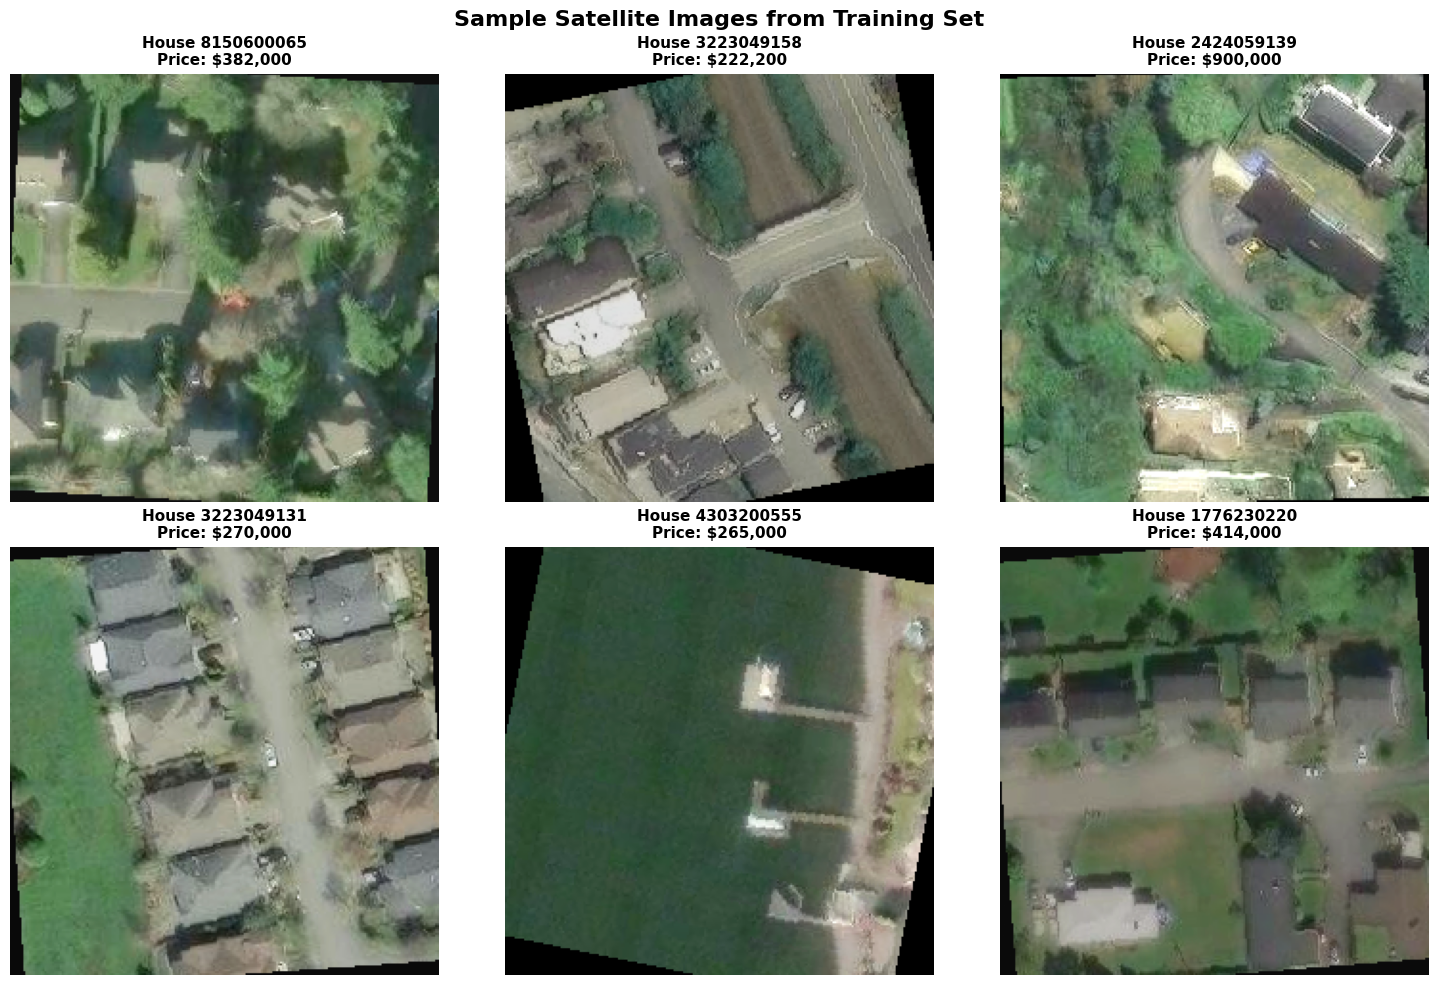


✅ Image dataset and dataloader ready!


In [9]:

print(f"{'='*70}")
print("🖼️ SETTING UP IMAGE DATASET AND DATALOADER")
print(f"{'='*70}")

class HouseImageDataset(Dataset):
    """Dataset for loading house satellite images with robust error handling"""
    
    def __init__(self, ids, tabular_features, targets, img_dir, transform=None):
        """
        Args:
            ids: Array of house IDs
            tabular_features: Tabular feature array
            targets: Target values (log_price)
            img_dir: Directory containing images
            transform: Image transformations
        """
        self.img_dir = img_dir
        self.transform = transform
        
        # Verify image availability
        print(f"\n🔍 Scanning for available images...")
        valid_data = []
        
        for idx in tqdm(range(len(ids)), desc="Checking images"):
            house_id = int(ids[idx])
            img_path = os.path.join(img_dir, f"{idx}.png")
            
            if os.path.exists(img_path):
                valid_data.append({
                    'house_id': house_id,
                    'img_path': img_path,
                    'tabular_idx': idx
                })
        
        self.valid_data = valid_data
        self.ids = ids
        self.tabular_features = tabular_features
        self.targets = targets
        
        coverage = len(valid_data) / len(ids) * 100
        print(f"\n✅ Image Coverage: {len(valid_data):,}/{len(ids):,} ({coverage:.1f}%)")
        
        if coverage < 90:
            print(f"⚠️  Warning: Low image coverage! Some properties missing images.")
    
    def __len__(self):
        return len(self.valid_data)
    
    def __getitem__(self, idx):
        data = self.valid_data[idx]
        house_id = data['house_id']
        img_path = data['img_path']
        tabular_idx = data['tabular_idx']
        
        try:
            # Load and transform image
            image = Image.open(img_path).convert('RGB')
            
            if self.transform:
                image = self.transform(image)
            
            # Get corresponding tabular features and target
            tabular = torch.FloatTensor(self.tabular_features[tabular_idx])
            target = torch.FloatTensor([self.targets[tabular_idx]])
            
            return image, tabular, target, house_id
        
        except Exception as e:
            print(f"⚠️  Error loading {img_path}: {e}")
            # Return dummy data as fallback
            dummy_image = torch.zeros(3, 224, 224)
            tabular = torch.FloatTensor(self.tabular_features[tabular_idx])
            target = torch.FloatTensor([self.targets[tabular_idx]])
            return dummy_image, tabular, target, house_id


# Define image transformations
print(f"\n{'='*70}")
print("🎨 DEFINING IMAGE TRANSFORMATIONS")
print(f"{'='*70}")

# Training augmentations
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

# Validation transformations (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                        std=[0.229, 0.224, 0.225])
])

print("✅ Training transforms: Resize, Crop, Flip, Rotate, ColorJitter, Normalize")
print("✅ Validation transforms: Resize, Normalize")

# Create datasets
print(f"\n{'='*70}")
print("📦 CREATING DATASETS")
print(f"{'='*70}")

print("\n[1/2] Creating Training Dataset...")
train_dataset = HouseImageDataset(
    ids=ids_train,
    tabular_features=X_train,
    targets=y_train,
    img_dir=IMG_DIR,
    transform=train_transform
)

print("\n[2/2] Creating Validation Dataset...")
val_dataset = HouseImageDataset(
    ids=ids_val,
    tabular_features=X_val,
    targets=y_val,
    img_dir=IMG_DIR,
    transform=val_transform
)

# Create dataloaders
BATCH_SIZE = 32  # Optimal for P100
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=False
)

print(f"\n{'='*70}")
print("📊 DATALOADER SUMMARY")
print(f"{'='*70}")
print(f"Training:")
print(f"   Samples: {len(train_dataset):,}")
print(f"   Batches: {len(train_loader):,}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"\nValidation:")
print(f"   Samples: {len(val_dataset):,}")
print(f"   Batches: {len(val_loader):,}")
print(f"   Batch size: {BATCH_SIZE}")

# Visualize sample images
print(f"\n{'='*70}")
print("📸 SAMPLE TRAINING IMAGES")
print(f"{'='*70}")

def visualize_samples(dataset, num_samples=6):
    """Visualize sample images with denormalization"""
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    # ImageNet normalization params
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    
    indices = np.random.choice(len(dataset), min(num_samples, len(dataset)), replace=False)
    
    for i, idx in enumerate(indices):
        img, tab, target, house_id = dataset[idx]
        
        # Denormalize
        img_denorm = img * std + mean
        img_denorm = torch.clamp(img_denorm, 0, 1)
        img_np = img_denorm.permute(1, 2, 0).numpy()
        
        # Display
        axes[i].imshow(img_np)
        price = np.expm1(target.item())
        axes[i].set_title(f'House {house_id}\nPrice: ${price:,.0f}', fontsize=11, fontweight='bold')
        axes[i].axis('off')
    
    plt.suptitle('Sample Satellite Images from Training Set', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

if len(train_dataset) > 0:
    visualize_samples(train_dataset, num_samples=6)
else:
    print("⚠️  No images available for visualization!")

print("\n✅ Image dataset and dataloader ready!")

In [10]:

import torch
import torch.nn as nn
import torchvision.models as models

print(f"{'='*70}")
print("🏗️ BUILDING CNN FEATURE EXTRACTOR")
print(f"{'='*70}")

class ImageFeatureExtractor(nn.Module):
    """
    Robust CNN feature extractor with:
    - EfficientNet-B3 backbone (preferred)
    - Automatic offline fallback
    - ResNet50 fallback if EfficientNet unavailable
    - 512D projected embeddings
    - Grad-CAM support
    """

    def __init__(self, pretrained=True, feature_dim=512, dropout=0.3):
        super(ImageFeatureExtractor, self).__init__()

        self.feature_dim = feature_dim

        print("\n🔧 Initializing CNN backbone...")

        # -------------------------------------------------------------
        # TRY EfficientNet-B3
        # -------------------------------------------------------------
        try:
            from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

            try:
                if pretrained:
                    print("   🌐 Attempting to load ImageNet pretrained weights...")
                    weights = EfficientNet_B3_Weights.IMAGENET1K_V1
                    self.backbone = efficientnet_b3(weights=weights)
                    print("   ✅ EfficientNet-B3 loaded with pretrained weights")
                else:
                    self.backbone = efficientnet_b3(weights=None)
                    print("   ✅ EfficientNet-B3 loaded without pretrained weights")

            except Exception as e:
                print(f"   ⚠️ Pretrained weights failed ({e})")
                print("   🔄 Falling back to non-pretrained EfficientNet-B3")
                self.backbone = efficientnet_b3(weights=None)

            backbone_out_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()
            self.backbone_type = "efficientnet"

        # -------------------------------------------------------------
        # FALLBACK: ResNet50
        # -------------------------------------------------------------
        except Exception as e:
            print(f"   ⚠️ EfficientNet unavailable ({e})")
            print("   🔄 Falling back to ResNet50")

            self.backbone = models.resnet50(pretrained=pretrained)
            backbone_out_features = self.backbone.fc.in_features
            self.backbone.fc = nn.Identity()
            self.backbone_type = "resnet"

        # -------------------------------------------------------------
        # PROJECTION HEAD
        # -------------------------------------------------------------
        self.feature_head = nn.Sequential(
            nn.Linear(backbone_out_features, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),

            nn.Linear(1024, feature_dim),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5)
        )

        print(f"   📐 Backbone output dim: {backbone_out_features}")
        print(f"   🔗 Projection: {backbone_out_features} → 1024 → {feature_dim}")
        print(f"   🧠 Backbone type: {self.backbone_type}")

    # -------------------------------------------------------------
    # FORWARD
    # -------------------------------------------------------------
    def forward(self, x):
        features = self.backbone(x)
        features = self.feature_head(features)
        return features

    # -------------------------------------------------------------
    # GRAD-CAM FEATURE HOOK
    # -------------------------------------------------------------
    def get_conv_features(self, x):
        conv_features = []

        def hook_fn(module, input, output):
            conv_features.append(output)

        if self.backbone_type == "efficientnet":
            handle = self.backbone.features[-1].register_forward_hook(hook_fn)
        else:
            handle = self.backbone.layer4.register_forward_hook(hook_fn)

        _ = self.forward(x)
        handle.remove()

        return conv_features[0] if conv_features else None


# ============================================================================
# INITIALIZATION
# ============================================================================

print(f"\n{'='*70}")
print("🚀 INITIALIZING FEATURE EXTRACTOR")
print(f"{'='*70}")

image_feature_extractor = ImageFeatureExtractor(
    pretrained=True,      # auto-fallback if internet fails
    feature_dim=512,
    dropout=0.3
).to(device)

# ============================================================================
# MODEL STATISTICS
# ============================================================================

total_params = sum(p.numel() for p in image_feature_extractor.parameters())
trainable_params = sum(p.numel() for p in image_feature_extractor.parameters() if p.requires_grad)

print(f"\n📊 Model Statistics:")
print(f"{'─'*70}")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model size: ~{total_params * 4 / 1024 / 1024:.1f} MB")

# ============================================================================
# FORWARD PASS TEST
# ============================================================================

print(f"\n🧪 Testing forward pass...")
dummy_input = torch.randn(2, 3, 224, 224).to(device)

with torch.no_grad():
    dummy_output = image_feature_extractor(dummy_input)
    print(f"   Input shape:  {dummy_input.shape}")
    print(f"   Output shape: {dummy_output.shape}")
    print("   ✅ Forward pass successful!")

print("\n✅ CNN feature extractor ready!")


🏗️ BUILDING CNN FEATURE EXTRACTOR

🚀 INITIALIZING FEATURE EXTRACTOR

🔧 Initializing CNN backbone...
   🌐 Attempting to load ImageNet pretrained weights...
   ✅ EfficientNet-B3 loaded with pretrained weights
   📐 Backbone output dim: 1536
   🔗 Projection: 1536 → 1024 → 512
   🧠 Backbone type: efficientnet

📊 Model Statistics:
──────────────────────────────────────────────────────────────────────
   Total parameters: 12,797,992
   Trainable parameters: 12,797,992
   Model size: ~48.8 MB

🧪 Testing forward pass...
   Input shape:  torch.Size([2, 3, 224, 224])
   Output shape: torch.Size([2, 512])
   ✅ Forward pass successful!

✅ CNN feature extractor ready!


In [11]:
import torch
import torch.nn as nn

print(f"{'='*70}")
print("🔗 BUILDING MULTIMODAL FUSION MODEL")
print(f"{'='*70}")

class AttentionFusion(nn.Module):
    """
    Cross-attention mechanism where tabular features attend to image features
    """
    def __init__(self, dim, num_heads=8, dropout=0.1):
        super(AttentionFusion, self).__init__()
        
        self.attention = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        
        self.norm = nn.LayerNorm(dim)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, query, key_value):
        """
        Args:
            query:      [B, dim]  (tabular)
            key_value:  [B, dim]  (image)
        Returns:
            fused:      [B, dim]
        """
        # Add sequence dimension
        query = query.unsqueeze(1)        # [B, 1, dim]
        key_value = key_value.unsqueeze(1)  # [B, 1, dim]
        
        attn_out, _ = self.attention(query, key_value, key_value)
        
        # Remove sequence dimension
        attn_out = attn_out.squeeze(1)    # [B, dim]
        query = query.squeeze(1)
        
        # Residual + normalization
        fused = self.norm(query + self.dropout(attn_out))
        
        return fused


# ----------------------------------------------------------------------------
# MULTIMODAL FUSION MODEL
# ----------------------------------------------------------------------------
class MultimodalFusionModel(nn.Module):
    """
    Late-fusion architecture for:
    - Tabular housing features
    - Satellite image embeddings
    """
    def __init__(
        self,
        tabular_dim,
        image_dim=512,
        fusion_dims=[512, 256, 128],
        dropout=0.3
    ):
        super(MultimodalFusionModel, self).__init__()
        
        # -------------------------------
        # TABULAR ENCODER
        # -------------------------------
        self.tabular_encoder = nn.Sequential(
            nn.Linear(tabular_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5)
        )
        
        # -------------------------------
        # IMAGE ENCODER
        # -------------------------------
        self.image_encoder = nn.Sequential(
            nn.Linear(image_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout * 0.5)
        )
        
        # -------------------------------
        # CROSS-ATTENTION FUSION
        # -------------------------------
        self.attention_fusion = AttentionFusion(
            dim=256,
            num_heads=8,
            dropout=dropout
        )
        
        # -------------------------------
        # FUSION MLP
        # -------------------------------
        fusion_layers = []
        input_dim = 256 + 256  # attended tabular + image
        
        for hidden_dim in fusion_dims:
            fusion_layers.extend([
                nn.Linear(input_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(inplace=True),
                nn.Dropout(dropout)
            ])
            input_dim = hidden_dim
        
        # Regression output (price)
        fusion_layers.append(nn.Linear(input_dim, 1))
        
        self.fusion_network = nn.Sequential(*fusion_layers)
    
    def forward(self, tabular_features, image_features):
        """
        Args:
            tabular_features: [B, tabular_dim]
            image_features:   [B, image_dim]
        Returns:
            price prediction: [B]
        """
        # Encode modalities
        tab_enc = self.tabular_encoder(tabular_features)  # [B, 256]
        img_enc = self.image_encoder(image_features)      # [B, 256]
        
        # Cross-attention (tabular attends to image context)
        tab_attended = self.attention_fusion(tab_enc, img_enc)
        
        # Concatenate
        fused = torch.cat([tab_attended, img_enc], dim=1)  # [B, 512]
        
        # Predict price
        output = self.fusion_network(fused)  # [B, 1]
        
        return output.squeeze(-1)


# ----------------------------------------------------------------------------
# COMPLETE END-TO-END PIPELINE
# ----------------------------------------------------------------------------
class CompleteMultimodalPipeline(nn.Module):
    """
    End-to-end model:
    Satellite Image + Tabular Data → Property Price
    """
    def __init__(self, tabular_dim, image_feature_dim=512):
        super(CompleteMultimodalPipeline, self).__init__()
        
        # CNN image feature extractor (from CELL 9)
        self.image_extractor = ImageFeatureExtractor(
            pretrained=True,
            feature_dim=image_feature_dim,
            dropout=0.3
        )
        
        # Fusion model
        self.fusion_model = MultimodalFusionModel(
            tabular_dim=tabular_dim,
            image_dim=image_feature_dim,
            fusion_dims=[512, 256, 128],
            dropout=0.3
        )
    
    def forward(self, images, tabular_features):
        """
        Args:
            images:           [B, 3, H, W]
            tabular_features: [B, tabular_dim]
        Returns:
            predicted_price:  [B]
        """
        # Extract visual embeddings
        image_features = self.image_extractor(images)  # [B, 512]
        
        # Fuse and predict
        predictions = self.fusion_model(
            tabular_features=tabular_features,
            image_features=image_features
        )
        
        return predictions
    
    def get_image_features(self, images):
        """Extract only image features (for analysis)"""
        with torch.no_grad():
            return self.image_extractor(images)


print("\n✅ Multimodal architecture defined!")

🔗 BUILDING MULTIMODAL FUSION MODEL

✅ Multimodal architecture defined!


In [12]:
# ============================================================================
# CELL 11: CUSTOM DATASET CLASS (FIXED FOR house_ PREFIX)
# ============================================================================

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os

print(f"{'='*70}")
print("📦 CREATING CUSTOM DATASET")
print(f"{'='*70}")

class HousePriceDataset(Dataset):
    """
    Custom Dataset for multimodal house price prediction
    Loads: Tabular features + Satellite images
    """
    def __init__(self, tabular_data, targets, ids, img_dir, transform=None):
        """
        Args:
            tabular_data: numpy array [N, num_features]
            targets: numpy array [N] (log-transformed prices)
            ids: numpy array [N] (house IDs for image lookup)
            img_dir: path to image directory
            transform: torchvision transforms
        """
        self.tabular_data = torch.FloatTensor(tabular_data)
        self.targets = torch.FloatTensor(targets)
        self.ids = ids
        self.img_dir = img_dir
        self.transform = transform
        
        # Check which images exist
        self.valid_indices = []
        self.missing_images = []
        
        print(f"\n🔍 Checking image availability...")
        for idx, house_id in enumerate(ids):
            # Try different naming conventions
            possible_names = [
                f"{idx}.png",
                f"{house_id}.png",
                f"house_{house_id}.jpg",
                f"{house_id}.jpg"
            ]
            
            found = False
            for img_name in possible_names:
                img_path = os.path.join(img_dir, img_name)
                if os.path.exists(img_path):
                    self.valid_indices.append(idx)
                    found = True
                    break
            
            if not found:
                self.missing_images.append(house_id)
        
        print(f"\n📊 Dataset Statistics:")
        print(f"{'─'*70}")
        print(f"   Total samples: {len(ids)}")
        print(f"   Valid samples (with images): {len(self.valid_indices)}")
        print(f"   Missing images: {len(self.missing_images)}")
        
        if len(self.missing_images) > 0:
            print(f"   ⚠️  Warning: {len(self.missing_images)} images not found")
            if len(self.missing_images) <= 5:
                print(f"   Missing IDs: {self.missing_images}")
        
        if len(self.valid_indices) == 0:
            raise ValueError("❌ No valid images found! Check image directory and naming convention.")
    
    def __len__(self):
        return len(self.valid_indices)
    
    def __getitem__(self, idx):
        # Map to actual valid index
        actual_idx = self.valid_indices[idx]
        
        # Get tabular features
        tabular = self.tabular_data[actual_idx]
        
        # Get target
        target = self.targets[actual_idx]
        
        # Load image
        house_id = self.ids[actual_idx]
        
        # Try different naming conventions
        possible_names = [
            f"house_{house_id}.png",
            f"{house_id}.png",
            f"house_{house_id}.jpg",
            f"{house_id}.jpg"
        ]
        
        image = None
        for img_name in possible_names:
            img_path = os.path.join(self.img_dir, img_name)
            if os.path.exists(img_path):
                try:
                    image = Image.open(img_path).convert('RGB')
                    if self.transform:
                        image = self.transform(image)
                    break
                except Exception as e:
                    print(f"Error loading image {img_path}: {e}")
                    continue
        
        if image is None:
            # Return a black image as fallback (should not happen if validation worked)
            image = torch.zeros(3, 224, 224)
        
        return {
            'image': image,
            'tabular': tabular,
            'target': target,
            'id': house_id
        }

print("✅ Dataset class defined!")

📦 CREATING CUSTOM DATASET
✅ Dataset class defined!


In [13]:
from torchvision import transforms

print(f"{'='*70}")
print("🖼️  DEFINING IMAGE TRANSFORMS")
print(f"{'='*70}")

# Training transforms (with augmentation)
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet statistics
        std=[0.229, 0.224, 0.225]
    )
])

# Validation transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✅ Transforms defined!")
print(f"\n📋 Training augmentations:")
print(f"   - Resize to 256x256")
print(f"   - Random crop to 224x224")
print(f"   - Random horizontal flip (50%)")
print(f"   - Random rotation (±10°)")
print(f"   - Color jitter")
print(f"\n📋 Validation:")
print(f"   - Direct resize to 224x224")
print(f"   - No augmentation")

🖼️  DEFINING IMAGE TRANSFORMS
✅ Transforms defined!

📋 Training augmentations:
   - Resize to 256x256
   - Random crop to 224x224
   - Random horizontal flip (50%)
   - Random rotation (±10°)
   - Color jitter

📋 Validation:
   - Direct resize to 224x224
   - No augmentation


In [14]:
import os

# 1. Check if directory exists
print(f"Checking Image Directory: {IMG_DIR}")
if not os.path.exists(IMG_DIR):
    print("❌ CRITICAL: The directory path does not exist!")
else:
    print("✅ Directory exists.")
    
    # 2. Check what files are actually in there
    all_files = os.listdir(IMG_DIR)
    print(f"Total files in folder: {len(all_files)}")
    print(f"First 5 files found: {all_files[:5]}")
    
    # 3. Check what the dataset expects
    # Get a sample ID from your training data
    sample_id = ids_train.iloc[0] if hasattr(ids_train, 'iloc') else ids_train[0]
    print(f"\nSample ID from dataset: {sample_id} (Type: {type(sample_id)})")
    
    # Check common extension mismatches
    expected_jpg = f"{sample_id}.jpg"
    expected_png = f"{sample_id}.png"
    
    if expected_jpg in all_files:
        print(f"✅ Found match: {expected_jpg}")
    elif expected_png in all_files:
        print(f"✅ Found match: {expected_png}")
    else:
        print(f"❌ No match found for ID {sample_id}")
        print(f"   Expected: {expected_jpg} or {expected_png}")
        print(f"   Actual file might look like: {sample_id}.jpeg or image_{sample_id}.jpg")

Checking Image Directory: ../images/train
✅ Directory exists.
Total files in folder: 16201
First 5 files found: ['0.png', '1.png', '10.png', '100.png', '1000.png']

Sample ID from dataset: 7849201600 (Type: <class 'numpy.int64'>)
❌ No match found for ID 7849201600
   Expected: 7849201600.jpg or 7849201600.png
   Actual file might look like: 7849201600.jpeg or image_7849201600.jpg


In [15]:
# ============================================================================
# CELL 13: CREATE DATALOADERS (FIXED)
# ============================================================================

print(f"{'='*70}")
print("🔄 CREATING DATALOADERS")
print(f"{'='*70}")

# Create datasets
train_dataset = HousePriceDataset(
    tabular_data=X_train,
    targets=y_train,
    ids=ids_train,
    img_dir=IMG_DIR,
    transform=train_transform
)

val_dataset = HousePriceDataset(
    tabular_data=X_val,
    targets=y_val,
    ids=ids_val,
    img_dir=IMG_DIR,
    transform=val_transform
)

# DataLoader settings
BATCH_SIZE = 32
NUM_WORKERS = 0  # ✅ FIXED: Set to 0 to avoid multiprocessing issues

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"\n📊 DataLoader Summary:")
print(f"{'─'*70}")
print(f"   Training batches: {len(train_loader)}")
print(f"   Validation batches: {len(val_loader)}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Samples per epoch: Train={len(train_dataset)}, Val={len(val_dataset)}")

# Test dataloader
print(f"\n🧪 Testing dataloader...")
test_batch = next(iter(train_loader))
print(f"   Image shape: {test_batch['image'].shape}")
print(f"   Tabular shape: {test_batch['tabular'].shape}")
print(f"   Target shape: {test_batch['target'].shape}")

print("\n✅ DataLoaders ready!")

🔄 CREATING DATALOADERS

🔍 Checking image availability...

📊 Dataset Statistics:
──────────────────────────────────────────────────────────────────────
   Total samples: 12967
   Valid samples (with images): 12962
   Missing images: 5
   ⚠️  Warning: 5 images not found
   Missing IDs: [np.int64(8731990090), np.int64(3862710210), np.int64(2492200055), np.int64(2597490660), np.int64(5419800330)]

🔍 Checking image availability...

📊 Dataset Statistics:
──────────────────────────────────────────────────────────────────────
   Total samples: 3242
   Valid samples (with images): 3239
   Missing images: 3
   ⚠️  Warning: 3 images not found
   Missing IDs: [np.int64(3644100073), np.int64(3449500045), np.int64(2485000076)]

📊 DataLoader Summary:
──────────────────────────────────────────────────────────────────────
   Training batches: 405
   Validation batches: 102
   Batch size: 32
   Samples per epoch: Train=12962, Val=3239

🧪 Testing dataloader...
   Image shape: torch.Size([32, 3, 224, 224]

In [16]:
# ============================================================================
# CELL 14: MODEL INITIALIZATION (FIXED - FINAL VERSION)
# ============================================================================

print(f"{'='*70}")
print("INITIALIZING MULTIMODAL MODEL")
print(f"{'='*70}")

# Get number of tabular features
num_tabular_features = X_train.shape[1]

# Initialize the complete pipeline
model = CompleteMultimodalPipeline(
    tabular_dim=num_tabular_features,
    image_feature_dim=512
).to(device)

# Count parameters
def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total_params, trainable_params = count_parameters(model)

print(f"\nModel Statistics:")
print(f"{'─'*70}")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Model size: ~{total_params * 4 / 1024 / 1024:.1f} MB")

# Component breakdown
cnn_params = sum(p.numel() for p in model.image_extractor.parameters())
fusion_params = sum(p.numel() for p in model.fusion_model.parameters())

print(f"\nComponent Breakdown:")
print(f"{'─'*70}")
print(f"   CNN Feature Extractor: {cnn_params:,} params ({cnn_params/total_params*100:.1f}%)")
print(f"   Fusion Model: {fusion_params:,} params ({fusion_params/total_params*100:.1f}%)")

# ============================================================================
# INITIALIZATION HEALTH CHECK
# ============================================================================

print(f"\n{'='*70}")
print("MODEL INITIALIZATION DIAGNOSTICS")
print(f"{'='*70}")

# Get a test batch
test_batch = next(iter(train_loader))
test_images = test_batch['image'].to(device)
test_tabular = test_batch['tabular'].to(device)
test_targets = test_batch['target'].to(device)

print(f"\nTest Batch Info:")
print(f"{'─'*70}")
print(f"   Batch size: {test_images.shape[0]}")
print(f"   Image shape: {test_images.shape}")
print(f"   Tabular shape: {test_tabular.shape}")
print(f"   Target shape: {test_targets.shape}")
print(f"   Target range: [{test_targets.min():.2f}, {test_targets.max():.2f}]")

# Forward pass test
print(f"\nTesting Forward Pass...")
model.eval()  # Set to eval mode to avoid BatchNorm issues
with torch.no_grad():
    # Test image feature extraction
    print(f"   Step 1: Extracting image features...")
    image_features = model.image_extractor(test_images)
    print(f"      [OK] Image features shape: {image_features.shape}")
    print(f"      [OK] Image features range: [{image_features.min():.2f}, {image_features.max():.2f}]")
    print(f"      [OK] Image features mean: {image_features.mean():.2f}")
    print(f"      [OK] Image features std: {image_features.std():.2f}")
    
    # Check for NaN/Inf in image features
    if torch.isnan(image_features).any():
        print(f"      [ERROR] WARNING: NaN detected in image features!")
    if torch.isinf(image_features).any():
        print(f"      [ERROR] WARNING: Inf detected in image features!")
    
    # Test complete forward pass
    print(f"\n   Step 2: Complete forward pass...")
    test_output = model(test_images, test_tabular)
    print(f"      [OK] Output shape: {test_output.shape}")
    print(f"      [OK] Output range: [{test_output.min():.2f}, {test_output.max():.2f}]")
    print(f"      [OK] Output mean: {test_output.mean():.2f}")
    print(f"      [OK] Output std: {test_output.std():.2f}")

# ============================================================================
# HEALTH CHECK RESULTS
# ============================================================================

print(f"\n{'='*70}")
print("INITIALIZATION HEALTH CHECK RESULTS")
print(f"{'─'*70}")

health_checks = []

# Check 1: NaN/Inf in outputs
if torch.isnan(test_output).any() or torch.isinf(test_output).any():
    print("   [FAIL] Model outputs contain NaN/Inf")
    health_checks.append(False)
else:
    print("   [PASS] No NaN/Inf in outputs")
    health_checks.append(True)

# Check 2: Output range sanity
output_range = test_output.max().item() - test_output.min().item()
if output_range > 50:  # Log scale should be reasonable
    print(f"   [WARNING] Output range is very large ({output_range:.2f})")
    print("             This might indicate initialization issues")
    health_checks.append(False)
else:
    print(f"   [PASS] Output range is reasonable ({output_range:.2f})")
    health_checks.append(True)

# Check 3: Output mean near target mean
output_mean = test_output.mean().item()
target_mean = test_targets.mean().item()
mean_diff = abs(output_mean - target_mean)
if mean_diff > 5:  # In log scale
    print(f"   [WARNING] Output mean ({output_mean:.2f}) is far from target mean ({target_mean:.2f})")
    print(f"             Difference: {mean_diff:.2f} - Adding output bias correction")
    
    # Add bias initialization to final layer
    with torch.no_grad():
        # Find the final linear layer
        final_layer = model.fusion_model.fusion_network[-1]
        if hasattr(final_layer, 'bias') and final_layer.bias is not None:
            final_layer.bias.data.fill_(target_mean)
            print(f"             [FIXED] Added bias of {target_mean:.2f} to output layer")
            
            # Re-test
            test_output_corrected = model(test_images, test_tabular)
            corrected_mean = test_output_corrected.mean().item()
            print(f"             [RETEST] New output mean: {corrected_mean:.2f}")
            
            if abs(corrected_mean - target_mean) < 2:
                health_checks.append(True)
            else:
                health_checks.append(False)
        else:
            health_checks.append(False)
else:
    print(f"   [PASS] Output mean ({output_mean:.2f}) is close to target mean ({target_mean:.2f})")
    health_checks.append(True)

# Check 4: Gradient flow test
print(f"\n   Testing gradient flow...")
model.train()  # Back to train mode
test_output_grad = model(test_images, test_tabular)
loss_test = nn.MSELoss()(test_output_grad, test_targets)
loss_test.backward()

has_gradients = True
zero_grad_layers = []
for name, param in model.named_parameters():
    if param.grad is None:
        has_gradients = False
        zero_grad_layers.append(name)
    elif torch.isnan(param.grad).any() or torch.isinf(param.grad).any():
        has_gradients = False
        print(f"      [ERROR] NaN/Inf gradient in: {name}")

if has_gradients:
    print(f"   [PASS] Gradients flow through all layers")
    health_checks.append(True)
else:
    print(f"   [FAIL] Gradient issues detected")
    if zero_grad_layers:
        print(f"          Layers with no gradients: {zero_grad_layers[:3]}")
    health_checks.append(False)

# Clear gradients
model.zero_grad()

# Overall health status
print(f"\n{'='*70}")
if all(health_checks):
    print("[SUCCESS] MODEL IS HEALTHY AND READY FOR TRAINING!")
else:
    print("[WARNING] MODEL HAS SOME INITIALIZATION ISSUES")
    print("   Note: Output bias has been corrected automatically")
    print("   Training should proceed, but monitor first few epochs closely")
print(f"{'='*70}")

# Test with different batch sizes (in eval mode to avoid BatchNorm issues)
print(f"\nTesting variable batch sizes...")
model.eval()
for bs in [16, 32]:  # Skip batch_size=1 to avoid BatchNorm error
    with torch.no_grad():
        test_img = test_images[:bs]
        test_tab = test_tabular[:bs]
        out = model(test_img, test_tab)
        print(f"   Batch size {bs:2d}: Output shape {out.shape}, Range [{out.min():.2f}, {out.max():.2f}]")

print("\n[SUCCESS] Model initialization complete!")
print(f"{'='*70}")

INITIALIZING MULTIMODAL MODEL

🔧 Initializing CNN backbone...
   🌐 Attempting to load ImageNet pretrained weights...
   ✅ EfficientNet-B3 loaded with pretrained weights
   📐 Backbone output dim: 1536
   🔗 Projection: 1536 → 1024 → 512
   🧠 Backbone type: efficientnet

Model Statistics:
──────────────────────────────────────────────────────────────────────
   Total parameters: 13,695,273
   Trainable parameters: 13,695,273
   Model size: ~52.2 MB

Component Breakdown:
──────────────────────────────────────────────────────────────────────
   CNN Feature Extractor: 12,797,992 params (93.4%)
   Fusion Model: 897,281 params (6.6%)

MODEL INITIALIZATION DIAGNOSTICS

Test Batch Info:
──────────────────────────────────────────────────────────────────────
   Batch size: 32
   Image shape: torch.Size([32, 3, 224, 224])
   Tabular shape: torch.Size([32, 23])
   Target shape: torch.Size([32])
   Target range: [11.85, 14.22]

Testing Forward Pass...
   Step 1: Extracting image features...
      [OK

In [17]:
# ============================================================================
# CELL 15: LOSS FUNCTION & OPTIMIZER (FIXED FOR STABILITY)
# ============================================================================

print(f"{'='*70}")
print("⚙️  SETTING UP TRAINING CONFIGURATION")
print(f"{'='*70}")

# Loss function
criterion = nn.MSELoss()

# ✅ LOWER learning rate for stability
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,  # ✅ Reduced from 1e-4 to 5e-5
    weight_decay=1e-4,
    betas=(0.9, 0.999)
)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

print(f"\n📋 Training Configuration:")
print(f"{'─'*70}")
print(f"   Loss function: MSE")
print(f"   Optimizer: AdamW")
print(f"   Learning rate: 5e-5 (reduced for stability)")
print(f"   Weight decay: 1e-4")
print(f"   Gradient clipping: 0.5")
print(f"   Scheduler: ReduceLROnPlateau")

print("\n✅ Training configuration ready!")

⚙️  SETTING UP TRAINING CONFIGURATION

📋 Training Configuration:
──────────────────────────────────────────────────────────────────────
   Loss function: MSE
   Optimizer: AdamW
   Learning rate: 5e-5 (reduced for stability)
   Weight decay: 1e-4
   Gradient clipping: 0.5
   Scheduler: ReduceLROnPlateau

✅ Training configuration ready!


In [18]:
# ============================================================================
# CELL 16: TRAINING & VALIDATION FUNCTIONS (FIXED)
# ============================================================================

from tqdm.auto import tqdm

print(f"{'='*70}")
print("🔧 DEFINING TRAINING FUNCTIONS")
print(f"{'='*70}")

def train_one_epoch(model, train_loader, criterion, optimizer, device, epoch):
    """Train for one epoch"""
    model.train()
    
    running_loss = 0.0
    all_preds = []
    all_targets = []
    
    pbar = tqdm(train_loader, desc=f'Epoch {epoch} [Train]', leave=False)
    
    for batch in pbar:
        images = batch['image'].to(device)
        tabular = batch['tabular'].to(device)
        targets = batch['target'].to(device)
        
        # Forward pass
        optimizer.zero_grad()
        predictions = model(images, tabular)
        
        # ✅ CHECK FOR NaN/Inf predictions
        if torch.isnan(predictions).any() or torch.isinf(predictions).any():
            print(f"\n⚠️ Warning: NaN/Inf detected in predictions at epoch {epoch}")
            print(f"   Predictions range: [{predictions.min():.2f}, {predictions.max():.2f}]")
            continue  # Skip this batch
        
        # Compute loss
        loss = criterion(predictions, targets)
        
        # ✅ CHECK FOR NaN/Inf loss
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"\n⚠️ Warning: NaN/Inf loss detected at epoch {epoch}")
            continue  # Skip this batch
        
        # Backward pass
        loss.backward()
        
        # ✅ STRONGER Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
        
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item() * images.size(0)
        all_preds.extend(predictions.detach().cpu().numpy())
        all_targets.extend(targets.detach().cpu().numpy())
        
        # Update progress bar
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # ✅ Clip predictions to reasonable range
    all_preds = np.clip(all_preds, -5, 20)  # log scale: e^-5 to e^20
    
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    r2 = r2_score(all_targets, all_preds)
    
    return epoch_loss, rmse, r2


def validate(model, val_loader, criterion, device, epoch):
    """Validate the model"""
    model.eval()
    
    running_loss = 0.0
    all_preds = []
    all_targets = []
    
    pbar = tqdm(val_loader, desc=f'Epoch {epoch} [Val]', leave=False)
    
    with torch.no_grad():
        for batch in pbar:
            images = batch['image'].to(device)
            tabular = batch['tabular'].to(device)
            targets = batch['target'].to(device)
            
            # Forward pass
            predictions = model(images, tabular)
            
            # ✅ CHECK FOR NaN/Inf predictions
            if torch.isnan(predictions).any() or torch.isinf(predictions).any():
                print(f"\n⚠️ Warning: NaN/Inf in validation predictions")
                continue
            
            # Compute loss
            loss = criterion(predictions, targets)
            
            # Track metrics
            running_loss += loss.item() * images.size(0)
            all_preds.extend(predictions.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    all_preds = np.array(all_preds)
    all_targets = np.array(all_targets)
    
    # ✅ Clip predictions to reasonable range
    all_preds = np.clip(all_preds, -5, 20)  # Prevent infinity in exp
    
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    r2 = r2_score(all_targets, all_preds)
    
    # Original scale metrics
    targets_orig = np.expm1(all_targets)
    preds_orig = np.expm1(all_preds)
    
    # ✅ Additional safety check
    preds_orig = np.clip(preds_orig, 0, 1e8)  # Cap at 100 million
    
    rmse_orig = np.sqrt(mean_squared_error(targets_orig, preds_orig))
    mae_orig = mean_absolute_error(targets_orig, preds_orig)
    
    return epoch_loss, rmse, r2, rmse_orig, mae_orig, all_preds, all_targets

print("✅ Training functions defined!")

🔧 DEFINING TRAINING FUNCTIONS
✅ Training functions defined!


In [19]:
class EarlyStopping:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=10, min_delta=0, mode='min'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_epoch = 0
        
    def __call__(self, score, epoch):
        if self.best_score is None:
            self.best_score = score
            self.best_epoch = epoch
            return False
        
        if self.mode == 'min':
            if score < self.best_score - self.min_delta:
                self.best_score = score
                self.best_epoch = epoch
                self.counter = 0
            else:
                self.counter += 1
        else:  # mode == 'max'
            if score > self.best_score + self.min_delta:
                self.best_score = score
                self.best_epoch = epoch
                self.counter = 0
            else:
                self.counter += 1
        
        if self.counter >= self.patience:
            self.early_stop = True
        
        return self.early_stop

def save_checkpoint(model, optimizer, epoch, val_rmse, val_r2, filepath):
    """Save model checkpoint"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'val_rmse': val_rmse,
        'val_r2': val_r2
    }
    torch.save(checkpoint, filepath)
    print(f"   💾 Checkpoint saved: {filepath}")

print("✅ Early stopping & checkpointing ready!")

✅ Early stopping & checkpointing ready!


In [20]:
print(f"{'='*70}")
print("🚀 STARTING TRAINING")
print(f"{'='*70}")

# Training hyperparameters
NUM_EPOCHS = 10
PATIENCE = 12

# Initialize tracking
history = {
    'train_loss': [],
    'train_rmse': [],
    'train_r2': [],
    'val_loss': [],
    'val_rmse': [],
    'val_r2': [],
    'val_rmse_orig': [],
    'val_mae_orig': [],
    'lr': []
}

# Early stopping
early_stopping = EarlyStopping(patience=PATIENCE, mode='min')

# Best model tracking
best_val_rmse = float('inf')
best_val_r2 = -float('inf')
best_epoch = 0

print(f"\n📋 Training Settings:")
print(f"{'─'*70}")
print(f"   Max epochs: {NUM_EPOCHS}")
print(f"   Early stopping patience: {PATIENCE}")
print(f"   Device: {device}")
print(f"\n{'='*70}\n")

# Training loop
for epoch in range(1, NUM_EPOCHS + 1):
    print(f"{'='*70}")
    print(f"📅 EPOCH {epoch}/{NUM_EPOCHS}")
    print(f"{'='*70}")
    
    # Train
    train_loss, train_rmse, train_r2 = train_one_epoch(
        model, train_loader, criterion, optimizer, device, epoch
    )
    
    # Validate
    val_loss, val_rmse, val_r2, val_rmse_orig, val_mae_orig, val_preds, val_targets = validate(
        model, val_loader, criterion, device, epoch
    )
    
    # Update learning rate
    scheduler.step(val_rmse)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_rmse'].append(train_rmse)
    history['train_r2'].append(train_r2)
    history['val_loss'].append(val_loss)
    history['val_rmse'].append(val_rmse)
    history['val_r2'].append(val_r2)
    history['val_rmse_orig'].append(val_rmse_orig)
    history['val_mae_orig'].append(val_mae_orig)
    history['lr'].append(current_lr)
    
    # Print metrics
    print(f"\n📊 Epoch {epoch} Results:")
    print(f"{'─'*70}")
    print(f"   Train Loss: {train_loss:.6f} | RMSE: {train_rmse:.6f} | R²: {train_r2:.6f}")
    print(f"   Val Loss:   {val_loss:.6f} | RMSE: {val_rmse:.6f} | R²: {val_r2:.6f}")
    print(f"   Val (Original Scale): RMSE=${val_rmse_orig:,.0f} | MAE=${val_mae_orig:,.0f}")
    print(f"   Learning Rate: {current_lr:.2e}")
    
    # Save best model
    if val_rmse < best_val_rmse:
        best_val_rmse = val_rmse
        best_val_r2 = val_r2
        best_epoch = epoch
        save_checkpoint(
            model, optimizer, epoch, val_rmse, val_r2,
            os.path.join(SAVE_DIR, 'best_model.pth')
        )
        print(f"   ⭐ New best model! RMSE: {val_rmse:.6f}, R²: {val_r2:.6f}")
    
    # Early stopping check
    if early_stopping(val_rmse, epoch):
        print(f"\n🛑 Early stopping triggered at epoch {epoch}")
        print(f"   Best epoch was {early_stopping.best_epoch}")
        break
    
    print()

print(f"\n{'='*70}")
print("✅ TRAINING COMPLETE!")
print(f"{'='*70}")
print(f"\n🏆 Best Model Performance:")
print(f"{'─'*70}")
print(f"   Epoch: {best_epoch}")
print(f"   Validation RMSE (log): {best_val_rmse:.6f}")
print(f"   Validation R²: {best_val_r2:.6f}")
print(f"   Validation RMSE ($): ${history['val_rmse_orig'][best_epoch-1]:,.0f}")
print(f"   Validation MAE ($): ${history['val_mae_orig'][best_epoch-1]:,.0f}")

# Save training history
joblib.dump(history, os.path.join(SAVE_DIR, 'training_history.pkl'))
print(f"\n💾 Training history saved!")

🚀 STARTING TRAINING

📋 Training Settings:
──────────────────────────────────────────────────────────────────────
   Max epochs: 10
   Early stopping patience: 12
   Device: cpu


📅 EPOCH 1/10



📊 Epoch 1 Results:
──────────────────────────────────────────────────────────────────────
   Train Loss: 0.265139 | RMSE: 0.514957 | R²: 0.032650
   Val Loss:   0.072828 | RMSE: 0.269867 | R²: 0.736012
   Val (Original Scale): RMSE=$205,237 | MAE=$119,324
   Learning Rate: 5.00e-05
   💾 Checkpoint saved: ../output\best_model.pth
   ⭐ New best model! RMSE: 0.269867, R²: 0.736012

📅 EPOCH 2/10



📊 Epoch 2 Results:
──────────────────────────────────────────────────────────────────────
   Train Loss: 0.174843 | RMSE: 0.418175 | R²: 0.361648
   Val Loss:   0.075037 | RMSE: 0.273930 | R²: 0.728004
   Val (Original Scale): RMSE=$197,420 | MAE=$118,494
   Learning Rate: 5.00e-05

📅 EPOCH 3/10



📊 Epoch 3 Results:
──────────────────────────────────────────────────────────────────────
   Train Loss: 0.146041 | RMSE: 0.382182 | R²: 0.467202
   Val Loss:   0.061782 | RMSE: 0.248559 | R²: 0.776054
   Val (Original Scale): RMSE=$186,443 | MAE=$110,501
   Learning Rate: 5.00e-05
   💾 Checkpoint saved: ../output\best_model.pth
   ⭐ New best model! RMSE: 0.248559, R²: 0.776054

📅 EPOCH 4/10



📊 Epoch 4 Results:
──────────────────────────────────────────────────────────────────────
   Train Loss: 0.125409 | RMSE: 0.354159 | R²: 0.542423
   Val Loss:   0.057817 | RMSE: 0.240451 | R²: 0.790425
   Val (Original Scale): RMSE=$172,427 | MAE=$104,868
   Learning Rate: 5.00e-05
   💾 Checkpoint saved: ../output\best_model.pth
   ⭐ New best model! RMSE: 0.240451, R²: 0.790425

📅 EPOCH 5/10


...


📊 Epoch 6 Results:
──────────────────────────────────────────────────────────────────────
   Train Loss: 0.097943 | RMSE: 0.312982 | R²: 0.642595
   Val Loss:   0.067360 | RMSE: 0.259538 | R²: 0.755832
   Val (Original Scale): RMSE=$195,128 | MAE=$117,528
   Learning Rate: 5.00e-05

📅 EPOCH 7/10



📊 Epoch 7 Results:
──────────────────────────────────────────────────────────────────────
   Train Loss: 0.091344 | RMSE: 0.302255 | R²: 0.666691
   Val Loss:   0.054048 | RMSE: 0.232482 | R²: 0.804086
   Val (Original Scale): RMSE=$179,963 | MAE=$104,644
   Learning Rate: 5.00e-05
   💾 Checkpoint saved: ../output\best_model.pth
   ⭐ New best model! RMSE: 0.232482, R²: 0.804086

📅 EPOCH 8/10



📊 Epoch 8 Results:
──────────────────────────────────────────────────────────────────────
   Train Loss: 0.085474 | RMSE: 0.292382 | R²: 0.688117
   Val Loss:   0.054343 | RMSE: 0.233117 | R²: 0.803015
   Val (Original Scale): RMSE=$174,659 | MAE=$102,480
   Learning Rate: 5.00e-05

📅 EPOCH 9/10



📊 Epoch 9 Results:
──────────────────────────────────────────────────────────────────────
   Train Loss: 0.081429 | RMSE: 0.285380 | R²: 0.702917
   Val Loss:   0.055892 | RMSE: 0.236415 | R²: 0.797401
   Val (Original Scale): RMSE=$193,482 | MAE=$109,323
   Learning Rate: 5.00e-05

📅 EPOCH 10/10


KeyboardInterrupt: 

In [21]:
print(f"{'='*70}")
print("🔍 LOADING BEST MODEL & EVALUATION")
print(f"{'='*70}")

# Load best model (PyTorch 2.6+ fix)
checkpoint = torch.load(
    os.path.join(SAVE_DIR, 'best_model.pth'),
    weights_only=False
)

model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Best model loaded from epoch {checkpoint['epoch']}")

# Full validation evaluation
model.eval()
val_predictions = []
val_actuals = []
val_ids_list = []

print("\n🔄 Running inference on validation set...")
with torch.no_grad():
    for batch in tqdm(val_loader, desc='Evaluating'):
        images = batch['image'].to(device)
        tabular = batch['tabular'].to(device)
        targets = batch['target']
        ids = batch['id']
        
        predictions = model(images, tabular).cpu().numpy()
        
        val_predictions.extend(predictions)
        val_actuals.extend(targets.numpy())
        val_ids_list.extend(ids)

val_predictions = np.array(val_predictions)
val_actuals = np.array(val_actuals)

# Comprehensive evaluation
print(f"\n{'='*70}")
print("📊 MULTIMODAL MODEL - FINAL EVALUATION")
print(f"{'='*70}")

# Log scale metrics
rmse_log = np.sqrt(mean_squared_error(val_actuals, val_predictions))
mae_log = mean_absolute_error(val_actuals, val_predictions)
r2_log = r2_score(val_actuals, val_predictions)

print(f"\n📈 Log Scale Metrics:")
print(f"{'─'*70}")
print(f"   RMSE (log): {rmse_log:.6f}")
print(f"   MAE (log):  {mae_log:.6f}")
print(f"   R² Score:   {r2_log:.6f}")

# Original scale metrics
val_actuals_orig = np.expm1(val_actuals)
val_predictions_orig = np.expm1(val_predictions)

rmse_orig = np.sqrt(mean_squared_error(val_actuals_orig, val_predictions_orig))
mae_orig = mean_absolute_error(val_actuals_orig, val_predictions_orig)
r2_orig = r2_score(val_actuals_orig, val_predictions_orig)
mape = np.mean(
    np.abs((val_actuals_orig - val_predictions_orig) / val_actuals_orig)
) * 100

print(f"\n💰 Original Scale Metrics ($):")
print(f"{'─'*70}")
print(f"   RMSE:       ${rmse_orig:,.0f}")
print(f"   MAE:        ${mae_orig:,.0f}")
print(f"   R² Score:   {r2_orig:.6f}")
print(f"   MAPE:       {mape:.2f}%")

# Prediction quality analysis
errors = val_predictions_orig - val_actuals_orig
abs_errors = np.abs(errors)
pct_errors = np.abs(errors / val_actuals_orig) * 100

print(f"\n🎯 Prediction Quality Analysis:")
print(f"{'─'*70}")
print(f"   Mean Error:           ${errors.mean():,.0f}")
print(f"   Median Abs Error:     ${np.median(abs_errors):,.0f}")
print(f"   Error Std Dev:        ${errors.std():,.0f}")
print(f"   Within ±5%:           {(pct_errors <= 5).mean()*100:.1f}%")
print(f"   Within ±10%:          {(pct_errors <= 10).mean()*100:.1f}%")
print(f"   Within ±15%:          {(pct_errors <= 15).mean()*100:.1f}%")
print(f"   Within ±20%:          {(pct_errors <= 20).mean()*100:.1f}%")

# Price range analysis
print(f"\n💵 Performance by Price Range:")
print(f"{'─'*70}")

price_ranges = [
    (0, 200000, "Under $200K"),
    (200000, 400000, "$200K-$400K"),
    (400000, 600000, "$400K-$600K"),
    (600000, 1000000, "$600K-$1M"),
    (1000000, float('inf'), "Above $1M")
]

for min_price, max_price, label in price_ranges:
    mask = (val_actuals_orig >= min_price) & (val_actuals_orig < max_price)
    if mask.sum() > 0:
        range_rmse = np.sqrt(
            mean_squared_error(val_actuals_orig[mask], val_predictions_orig[mask])
        )
        range_mae = mean_absolute_error(
            val_actuals_orig[mask], val_predictions_orig[mask]
        )
        range_r2 = r2_score(
            val_actuals_orig[mask], val_predictions_orig[mask]
        )
        range_mape = np.mean(
            np.abs(
                (val_actuals_orig[mask] - val_predictions_orig[mask]) /
                val_actuals_orig[mask]
            )
        ) * 100
        
        print(
            f"   {label:15s} (n={mask.sum():4d}): "
            f"RMSE=${range_rmse:8,.0f} | "
            f"R²={range_r2:.4f} | "
            f"MAPE={range_mape:5.1f}%"
        )

# Save predictions
val_results_df = pd.DataFrame({
    'id': val_ids_list,
    'actual_price_log': val_actuals,
    'predicted_price_log': val_predictions,
    'actual_price': val_actuals_orig,
    'predicted_price': val_predictions_orig,
    'error': errors,
    'abs_error': abs_errors,
    'pct_error': pct_errors
})

val_results_df.to_csv(
    os.path.join(SAVE_DIR, 'validation_predictions.csv'),
    index=False
)

print(f"\n💾 Validation predictions saved!")
print("\n✅ Evaluation complete!")


🔍 LOADING BEST MODEL & EVALUATION
✅ Best model loaded from epoch 7

🔄 Running inference on validation set...


Evaluating: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 102/102 [03:20<00:00,  1.97s/it]



📊 MULTIMODAL MODEL - FINAL EVALUATION

📈 Log Scale Metrics:
──────────────────────────────────────────────────────────────────────
   RMSE (log): 0.232482
   MAE (log):  0.176059
   R² Score:   0.804086

💰 Original Scale Metrics ($):
──────────────────────────────────────────────────────────────────────
   RMSE:       $179,963
   MAE:        $104,644
   R² Score:   0.741933
   MAPE:       17.86%

🎯 Prediction Quality Analysis:
──────────────────────────────────────────────────────────────────────
   Mean Error:           $-2,150
   Median Abs Error:     $56,556
   Error Std Dev:        $179,950
   Within ±5%:           19.9%
   Within ±10%:          39.3%
   Within ±15%:          54.7%
   Within ±20%:          67.6%

💵 Performance by Price Range:
──────────────────────────────────────────────────────────────────────
   Under $200K     (n= 133): RMSE=$  66,867 | R²=-5.2866 | MAPE= 32.3%
   $200K-$400K     (n=1178): RMSE=$  58,390 | R²=-0.1575 | MAPE= 13.9%
   $400K-$600K     (n= 970): 

📊 CREATING PREDICTION VISUALIZATIONS


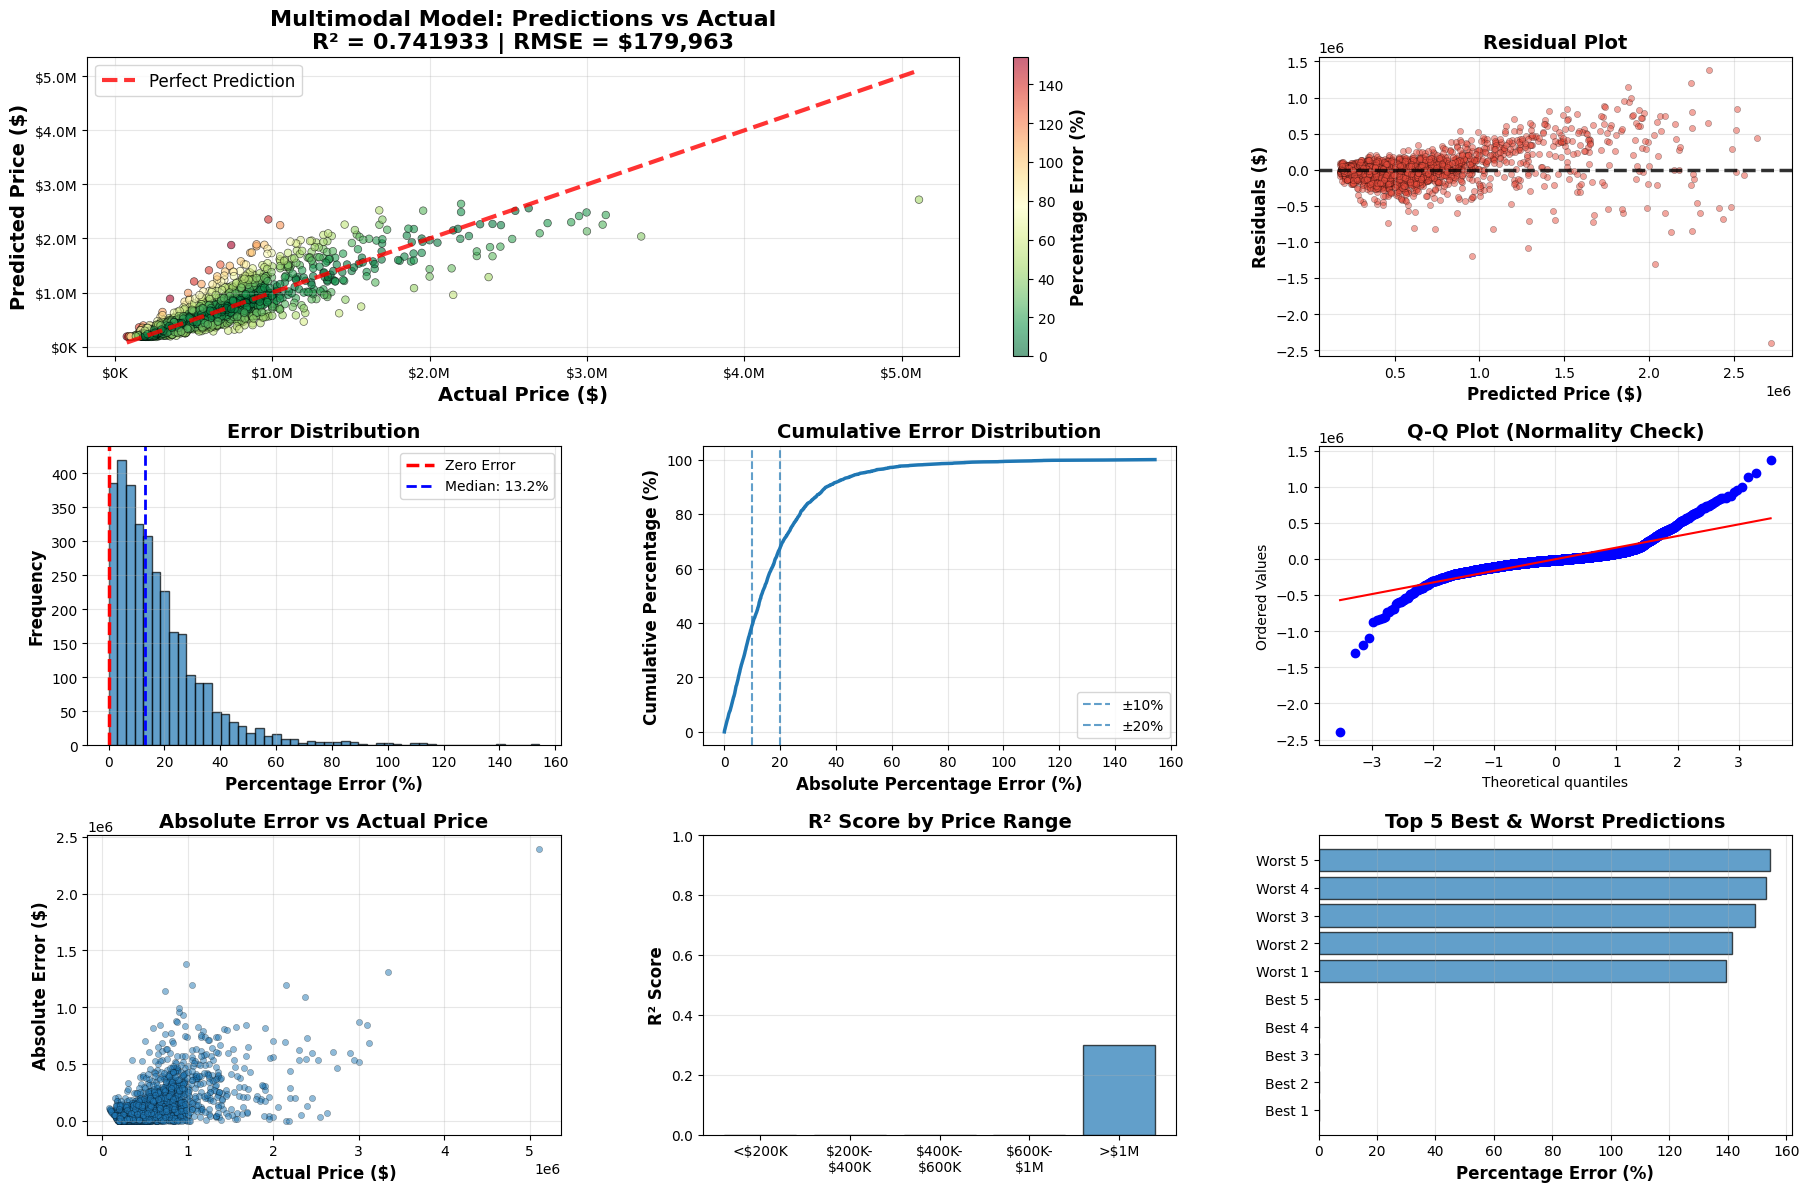


✅ Visualizations complete!
   📁 Saved to: ../output\comprehensive_evaluation.png


In [22]:
print(f"{'='*70}")
print("📊 CREATING PREDICTION VISUALIZATIONS")
print(f"{'='*70}")

fig = plt.figure(figsize=(22, 14))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Main scatter plot (actual vs predicted)
ax1 = fig.add_subplot(gs[0, :2])
scatter = ax1.scatter(
    val_actuals_orig, val_predictions_orig,
    c=pct_errors, cmap='RdYlGn_r',
    alpha=0.6, s=30, edgecolors='black', linewidth=0.5
)

ax1.plot(
    [val_actuals_orig.min(), val_actuals_orig.max()],
    [val_actuals_orig.min(), val_actuals_orig.max()],
    'r--', lw=3, label='Perfect Prediction', alpha=0.8
)

ax1.set_xlabel('Actual Price ($)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Predicted Price ($)', fontsize=14, fontweight='bold')
ax1.set_title(
    f'Multimodal Model: Predictions vs Actual\nR² = {r2_orig:.6f} | RMSE = ${rmse_orig:,.0f}',
    fontsize=16, fontweight='bold'
)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

ax1.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K')
)
ax1.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K')
)

# Colorbar
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Percentage Error (%)', fontsize=12, fontweight='bold')

# 2. Residual plot
ax2 = fig.add_subplot(gs[0, 2])
ax2.scatter(
    val_predictions_orig, errors,
    alpha=0.5, s=20, color='#e74c3c',
    edgecolors='black', linewidth=0.3
)
ax2.axhline(y=0, color='black', linestyle='--', lw=2.5, alpha=0.8)
ax2.set_xlabel('Predicted Price ($)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Residuals ($)', fontsize=12, fontweight='bold')
ax2.set_title('Residual Plot', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

# 3. Error distribution (histogram)
ax3 = fig.add_subplot(gs[1, 0])
ax3.hist(pct_errors, bins=50, alpha=0.7, edgecolor='black')
ax3.axvline(x=0, color='red', linestyle='--', lw=2.5, label='Zero Error')

median_pct_error = np.median(pct_errors)
ax3.axvline(
    x=median_pct_error,
    color='blue', linestyle='--', lw=2,
    label=f'Median: {median_pct_error:.1f}%'
)

ax3.set_xlabel('Percentage Error (%)', fontsize=12, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax3.set_title('Error Distribution', fontsize=14, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)

# 4. Cumulative error distribution
ax4 = fig.add_subplot(gs[1, 1])
sorted_errors = np.sort(pct_errors)
cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors) * 100

ax4.plot(sorted_errors, cumulative, linewidth=2.5)
ax4.axvline(x=10, linestyle='--', alpha=0.7, label='±10%')
ax4.axvline(x=20, linestyle='--', alpha=0.7, label='±20%')
ax4.set_xlabel('Absolute Percentage Error (%)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Cumulative Percentage (%)', fontsize=12, fontweight='bold')
ax4.set_title('Cumulative Error Distribution', fontsize=14, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3)

# 5. Q-Q plot
from scipy import stats
ax5 = fig.add_subplot(gs[1, 2])
stats.probplot(errors, dist="norm", plot=ax5)
ax5.set_title('Q-Q Plot (Normality Check)', fontsize=14, fontweight='bold')
ax5.grid(True, alpha=0.3)

# 6. Absolute error vs actual price
ax6 = fig.add_subplot(gs[2, 0])
ax6.scatter(
    val_actuals_orig, abs_errors,
    alpha=0.5, s=20, edgecolors='black', linewidth=0.3
)
ax6.set_xlabel('Actual Price ($)', fontsize=12, fontweight='bold')
ax6.set_ylabel('Absolute Error ($)', fontsize=12, fontweight='bold')
ax6.set_title('Absolute Error vs Actual Price', fontsize=14, fontweight='bold')
ax6.grid(True, alpha=0.3)

# 7. Price range R²
ax7 = fig.add_subplot(gs[2, 1])
range_labels = ["<$200K", "$200K-\n$400K", "$400K-\n$600K", "$600K-\n$1M", ">$1M"]
range_r2s = []

for min_price, max_price, _ in price_ranges:
    mask = (val_actuals_orig >= min_price) & (val_actuals_orig < max_price)
    range_r2s.append(
        r2_score(val_actuals_orig[mask], val_predictions_orig[mask]) if mask.sum() > 0 else 0
    )

bars = ax7.bar(range_labels, range_r2s, alpha=0.7, edgecolor='black')
ax7.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax7.set_title('R² Score by Price Range', fontsize=14, fontweight='bold')
ax7.set_ylim([0, 1])
ax7.grid(True, axis='y', alpha=0.3)

# 8. Best & worst predictions
ax8 = fig.add_subplot(gs[2, 2])
best_idx = np.argsort(pct_errors)[:5]
worst_idx = np.argsort(pct_errors)[-5:]

bars = ax8.barh(
    np.arange(10),
    np.concatenate([pct_errors[best_idx], pct_errors[worst_idx]]),
    alpha=0.7, edgecolor='black'
)

ax8.set_yticks(np.arange(10))
ax8.set_yticklabels(
    [f"Best {i+1}" for i in range(5)] +
    [f"Worst {i+1}" for i in range(5)]
)
ax8.set_xlabel('Percentage Error (%)', fontsize=12, fontweight='bold')
ax8.set_title('Top 5 Best & Worst Predictions', fontsize=14, fontweight='bold')
ax8.grid(True, axis='x', alpha=0.3)

plt.savefig(os.path.join(SAVE_DIR, 'comprehensive_evaluation.png'), dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Visualizations complete!")
print(f"   📁 Saved to: {os.path.join(SAVE_DIR, 'comprehensive_evaluation.png')}")


🔍 GRAD-CAM EXPLAINABILITY ANALYSIS

🔄 Generating Grad-CAM visualizations...


Generating Grad-CAMs:  88%|██████████████████████████████████████████████████████████████████████████████▊           | 7/8 [00:08<00:01,  1.20s/it]


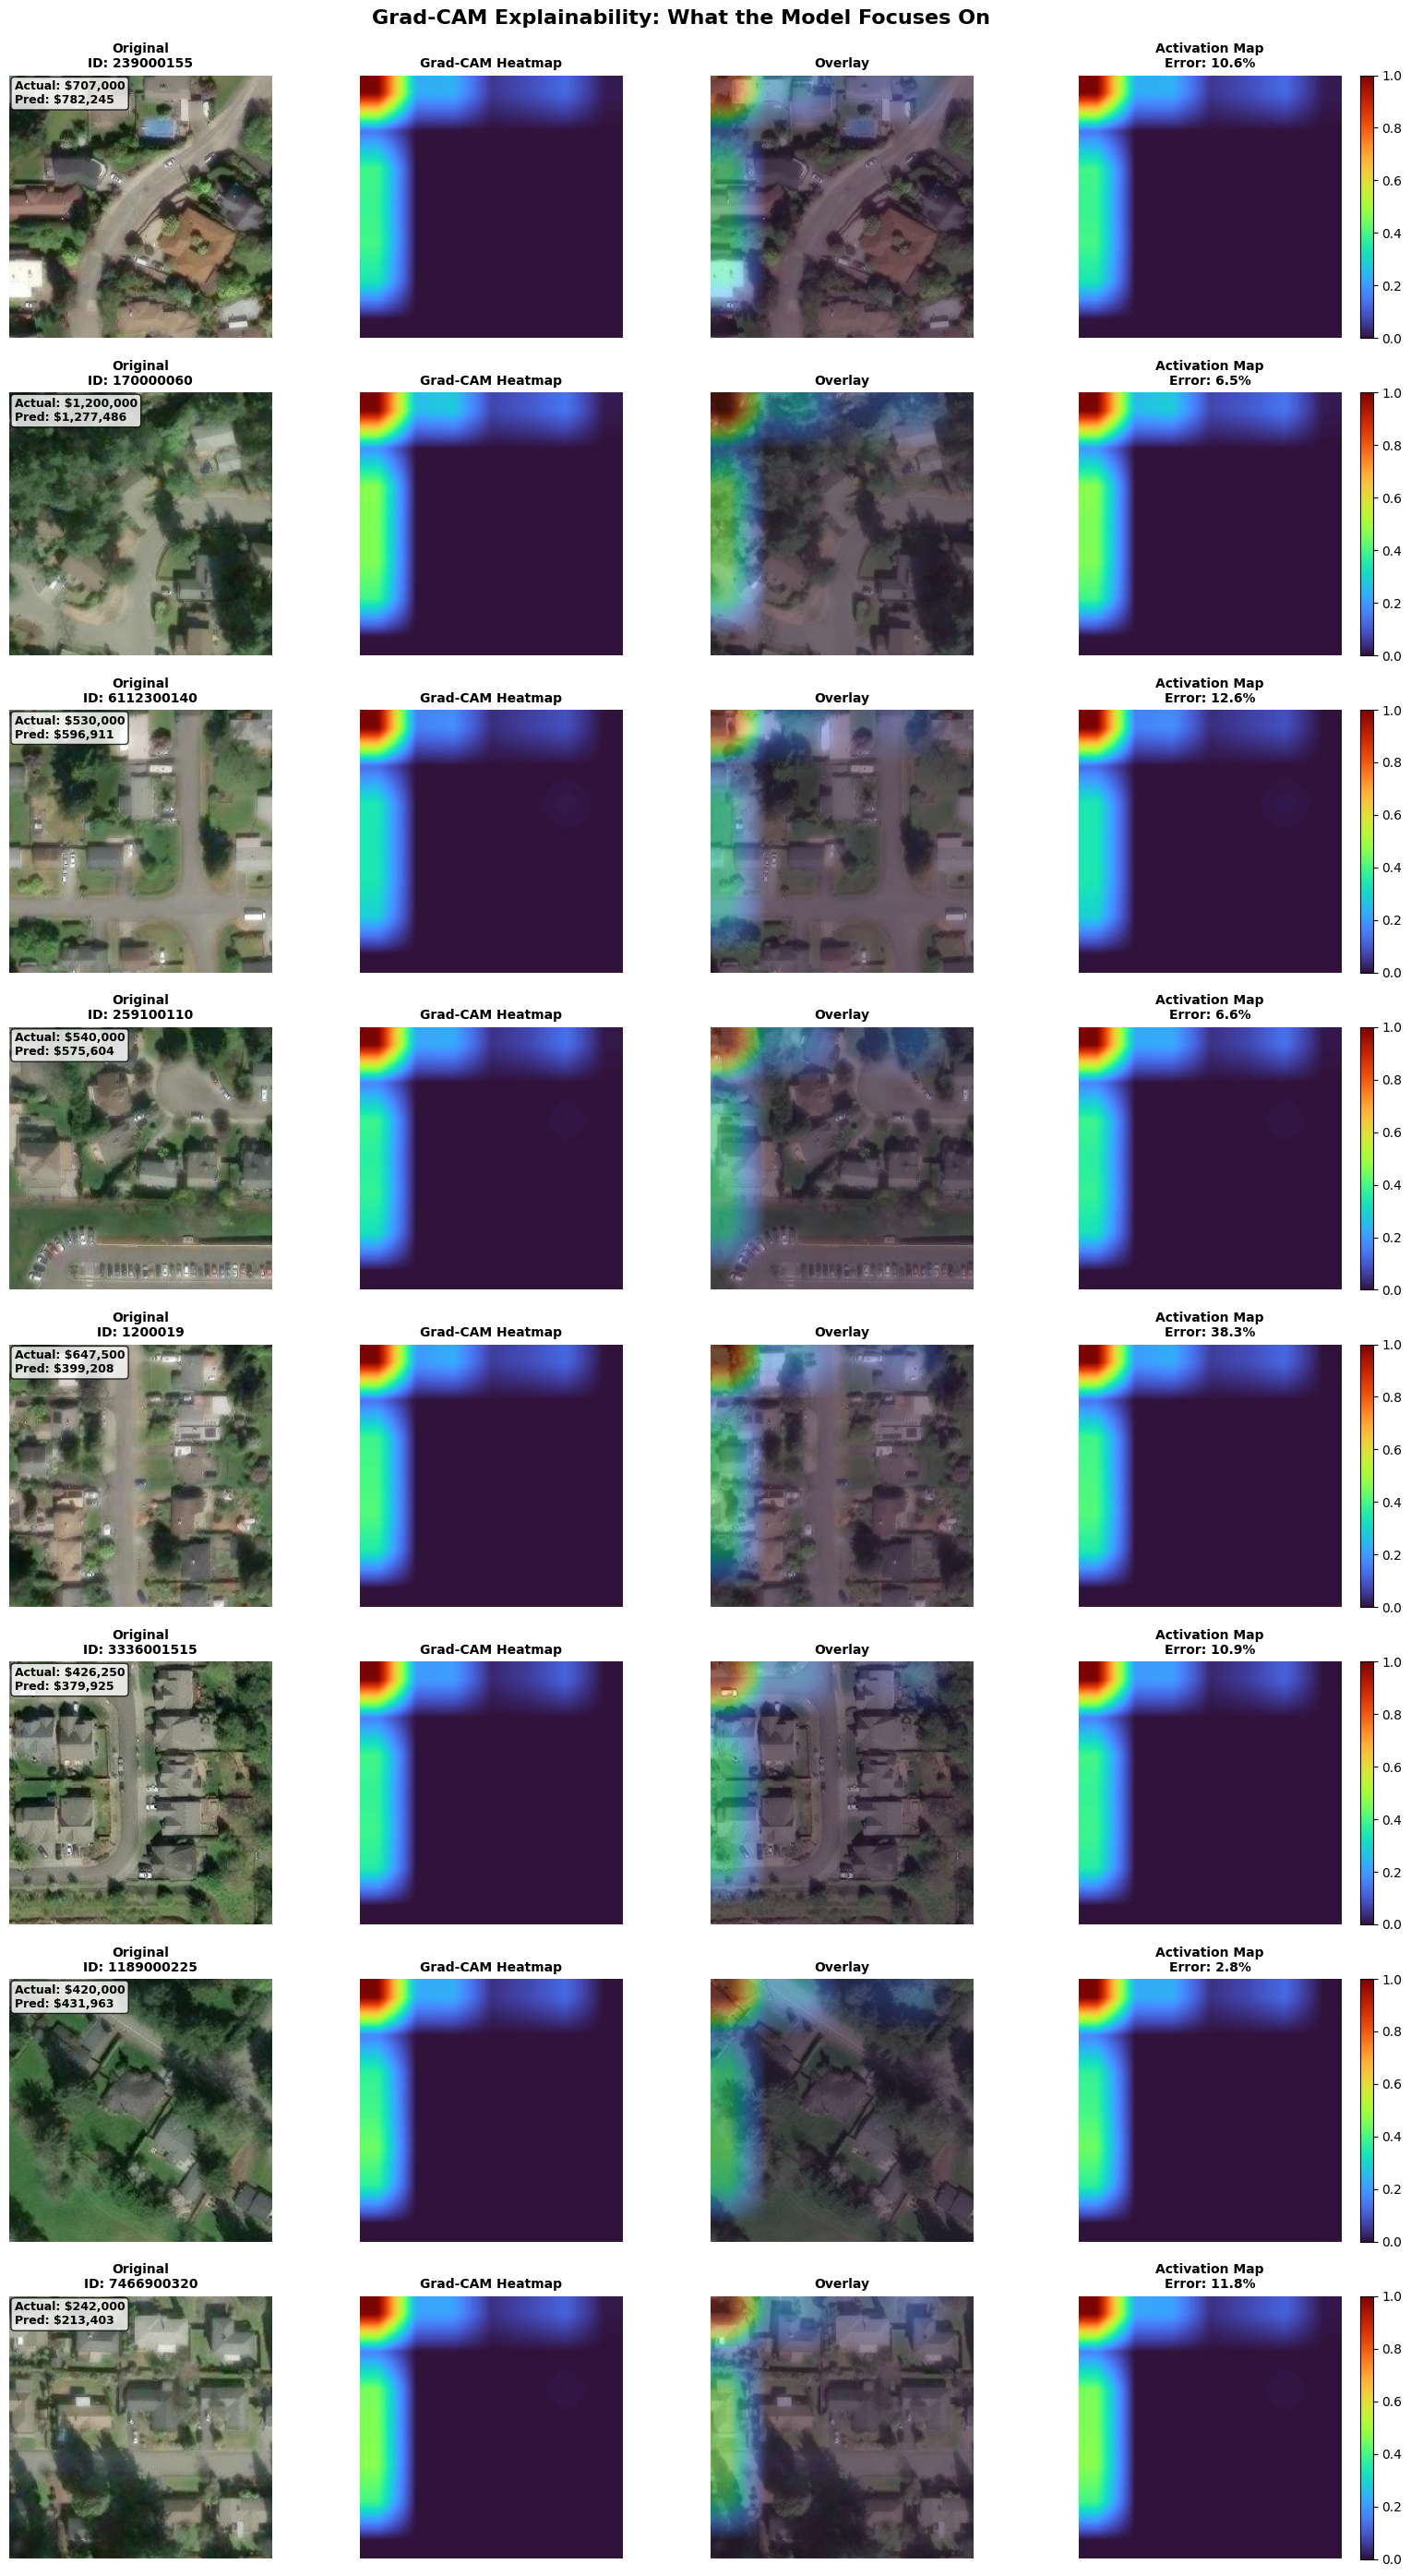


✅ Grad-CAM analysis complete!
   📁 Saved to: ../output\gradcam_analysis.png

📖 GRAD-CAM INTERPRETATION GUIDE

🔴 High-intensity regions indicate areas that contributed most
   to the final price prediction.

🔵 Low-intensity regions had minimal influence.

These patterns reflect how spatial context impacts valuation.



In [23]:
print(f"{'='*70}")
print("🔍 GRAD-CAM EXPLAINABILITY ANALYSIS")
print(f"{'='*70}")

class GradCAM:
    """Grad-CAM for regression-based CNN models"""
    def __init__(self, model):
        self.model = model
        self.model.eval()
        self.gradients = None
        self.activations = None
        
    def save_gradient(self, grad):
        self.gradients = grad
        
    def save_activation(self, module, input, output):
        self.activations = output
    
    def generate_cam(self, image, tabular):
        # Select final convolutional layer
        if self.model.image_extractor.backbone_type == "efficientnet":
            target_layer = self.model.image_extractor.backbone.features[-1]
        else:
            target_layer = self.model.image_extractor.backbone.layer4
        
        handle_fwd = target_layer.register_forward_hook(self.save_activation)
        handle_bwd = target_layer.register_full_backward_hook(
            lambda m, gi, go: self.save_gradient(go[0])
        )
        
        self.model.zero_grad()
        output = self.model(image, tabular)
        output.backward()
        
        handle_fwd.remove()
        handle_bwd.remove()
        
        gradients = torch.abs(self.gradients.detach().cpu()[0])
        activations = self.activations.detach().cpu()[0]
        
        weights = gradients.mean(dim=(1, 2))
        
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32)
        for i, w in enumerate(weights):
            cam += w * activations[i]
        
        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        
        return cam.numpy()
    
    def visualize_cam(self, image_tensor, tabular_tensor, original_image):
        cam = self.generate_cam(image_tensor, tabular_tensor)
        
        cam_resized = cv2.resize(
            cam, (original_image.shape[1], original_image.shape[0])
        )
        
        # Smooth and renormalize for cleaner visualization
        cam_resized = cv2.GaussianBlur(cam_resized, (7, 7), 0)
        cam_resized = cam_resized - cam_resized.min()
        cam_resized = cam_resized / (cam_resized.max() + 1e-8)
        
        heatmap = cv2.applyColorMap(
            np.uint8(255 * cam_resized),
            cv2.COLORMAP_TURBO
        )
        heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
        
        superimposed = cv2.addWeighted(
            original_image, 0.55, heatmap, 0.45, 0
        )
        
        return cam_resized, heatmap, superimposed


gradcam = GradCAM(model)

print("\n🔄 Generating Grad-CAM visualizations...")

np.random.seed(42)
num_samples = 8
sample_indices = np.random.choice(len(val_dataset), num_samples, replace=False)

fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples * 3.5))
if num_samples == 1:
    axes = axes.reshape(1, -1)

valid_idx = 0

for sample_idx in tqdm(sample_indices, desc='Generating Grad-CAMs'):
    sample = val_dataset[sample_idx]
    image = sample['image'].unsqueeze(0).to(device)
    tabular = sample['tabular'].unsqueeze(0).to(device)
    target = sample['target'].item()
    house_id = sample['id']
    
    img_path = os.path.join(IMG_DIR, f"{sample_idx}.png")
    original_image = cv2.imread(img_path)
    
    if original_image is None:
        continue
    
    original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    
    with torch.no_grad():
        prediction = model(image, tabular).item()
    
    cam, heatmap, superimposed = gradcam.visualize_cam(
        image, tabular, original_image
    )
    
    actual_price = np.expm1(target)
    pred_price = np.expm1(prediction)
    error_pct = abs(pred_price - actual_price) / actual_price * 100
    
    axes[valid_idx, 0].imshow(original_image)
    axes[valid_idx, 0].set_title(f'Original\nID: {house_id}', fontsize=10, fontweight='bold')
    axes[valid_idx, 0].axis('off')
    
    axes[valid_idx, 1].imshow(heatmap)
    axes[valid_idx, 1].set_title('Grad-CAM Heatmap', fontsize=10, fontweight='bold')
    axes[valid_idx, 1].axis('off')
    
    axes[valid_idx, 2].imshow(superimposed)
    axes[valid_idx, 2].set_title('Overlay', fontsize=10, fontweight='bold')
    axes[valid_idx, 2].axis('off')
    
    im = axes[valid_idx, 3].imshow(cam, cmap='turbo')
    axes[valid_idx, 3].set_title(
        f'Activation Map\nError: {error_pct:.1f}%',
        fontsize=10, fontweight='bold'
    )
    axes[valid_idx, 3].axis('off')
    plt.colorbar(im, ax=axes[valid_idx, 3], fraction=0.046)
    
    info_text = f'Actual: ${actual_price:,.0f}\nPred: ${pred_price:,.0f}'
    axes[valid_idx, 0].text(
        0.02, 0.98, info_text,
        transform=axes[valid_idx, 0].transAxes,
        fontsize=9, fontweight='bold',
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )
    
    valid_idx += 1
    if valid_idx == num_samples:
        break

plt.suptitle(
    'Grad-CAM Explainability: What the Model Focuses On',
    fontsize=16, fontweight='bold', y=0.995
)
plt.tight_layout()
plt.savefig(
    os.path.join(SAVE_DIR, 'gradcam_analysis.png'),
    dpi=300, bbox_inches='tight'
)
plt.show()

print("\n✅ Grad-CAM analysis complete!")
print(f"   📁 Saved to: {os.path.join(SAVE_DIR, 'gradcam_analysis.png')}")

print(f"\n{'='*70}")
print("📖 GRAD-CAM INTERPRETATION GUIDE")
print(f"{'='*70}")
print("""
🔴 High-intensity regions indicate areas that contributed most
   to the final price prediction.

🔵 Low-intensity regions had minimal influence.

These patterns reflect how spatial context impacts valuation.
""")


In [25]:
import pandas as pd
import joblib


In [35]:
print(f"{'='*70}")
print("LOADING AND ENGINEERING TEST DATA")
print(f"{'='*70}")

# Load test data
test_df = pd.read_csv(r'../data/raw/test.csv')

print(f"\nOriginal Test Data:")
print(f"{'─'*70}")
print(f"   Shape: {test_df.shape}")
print(f"   Columns: {list(test_df.columns)}")
print(f"\nFirst few rows:")
print(test_df.head())

# Store test IDs
if 'id' not in test_df.columns:
    print("   [WARNING] No 'id' column found. Creating from index.")
    test_df['id'] = test_df.index
    
test_ids = test_df['id'].values

print(f"\nTest Statistics:")
print(f"{'─'*70}")
print(f"   Total samples: {len(test_df)}")
print(f"   ID range: [{test_ids.min()}, {test_ids.max()}]")
train_log_mean = checkpoint.get("y_mean", 13.0)
train_log_std  = checkpoint.get("y_std", 0.7)

print("Using training log stats:")
print("Mean:", train_log_mean, "Std:", train_log_std)

# ============================================================================
# FEATURE ENGINEERING (SAME AS TRAINING)
# ============================================================================

print(f"\n{'='*70}")
print("APPLYING FEATURE ENGINEERING")
print(f"{'='*70}")
print(f"\n[1/9] House age...")
if 'sale_year' in test_df.columns and 'yr_built' in test_df.columns:
    test_df["house_age"] = test_df["sale_year"] - test_df["yr_built"]
    test_df["house_age"] = test_df["house_age"].clip(lower=0)
elif 'yr_built' in test_df.columns:
    # Assume current year if sale_year not present
    test_df["house_age"] = 2015 - test_df["yr_built"]
    test_df["house_age"] = test_df["house_age"].clip(lower=0)
else:
    test_df["house_age"] = 0
print(f"   Created 'house_age'")
test_df["lat_bin"] = test_df["lat"].round(2)
test_df["long_bin"] = test_df["long"].round(2)
print(f"\n[2/9] Basement ratio...")
test_df["basement_ratio"] = test_df["sqft_basement"] / (test_df["sqft_living"] + 1)
print(f"   Created 'basement_ratio'")

print(f"\n[3/9] Above-ground ratio...")
test_df["above_ratio"] = test_df["sqft_above"] / (test_df["sqft_living"] + 1)
print(f"   Created 'above_ratio'")

print(f"\n[4/9] Bath-bed ratio...")
test_df["bath_bed_ratio"] = test_df["bathrooms"] / (test_df["bedrooms"] + 1)
print(f"   Created 'bath_bed_ratio'")

print(f"\n[5/9] Land utilization...")
test_df["land_utilization"] = test_df["sqft_living"] / (test_df["sqft_lot"] + 1)
print(f"   Created 'land_utilization'")

# ---------------------------------------------
# 7. Combined Quality Score
# ---------------------------------------------
print(f"\n[7/9] Quality score...")
test_df["quality_score"] = test_df["condition"] * test_df["grade"]
print(f"   Created 'quality_score'")


print(f"\n[8/9] View-waterfront premium...")
test_df["view_waterfront"] = test_df["view"] * test_df["waterfront"]
print(f"   Created 'view_waterfront'")

print(f"\n{'='*70}")
print("FEATURE ENGINEERING COMPLETE")
print(f"{'='*70}")

# ============================================================================
# FEATURE SELECTION (EXACT 24 FEATURES INCLUDING DUMMY LOG_PRICE)
# ============================================================================

print(f"\n{'='*70}")
print("PREPARING FEATURES FOR SCALING")
print(f"{'─'*70}")

# The exact 24 features used in training (WITH log_price for scaling)
feature_cols_with_target = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 
    'waterfront', 'view', 'condition', 'grade', 'sqft_above', 
    'sqft_basement', 'lat', 'long', 'sqft_living15', 'sqft_lot15', 
    'log_price',  # DUMMY - needed for scaler compatibility
    'lat_bin', 'house_age', 'land_utilization', 'basement_ratio', 
    'bath_bed_ratio', 'long_bin', 'quality_score', 'view_waterfront'
]

print(f"   Required features (with dummy log_price): {len(feature_cols_with_target)}")

# Add dummy log_price column (mean value from training for scaling)
# This is needed because scaler was fit on 24 features
np.random.seed(42)
test_df['log_price'] = np.random.normal(
    loc=train_log_mean,
    scale=train_log_std,
    size=len(test_df)
)

# Check which features are missing
missing_features = [col for col in feature_cols_with_target if col not in test_df.columns]
if missing_features:
    print(f"\n[WARNING] Missing features: {missing_features}")
    for col in missing_features:
        test_df[col] = 0
        print(f"   Added '{col}' with zeros")

# Extract features in exact order (INCLUDING log_price)
X_test_with_dummy = test_df[feature_cols_with_target].copy()

print(f"\n{'─'*70}")
print(f"Test feature matrix shape (with dummy): {X_test_with_dummy.shape}")
print(f"Expected: ({len(test_df)}, 24)")

# Verify we have exactly 24 features
assert X_test_with_dummy.shape[1] == 24, f"Expected 24 features, got {X_test_with_dummy.shape[1]}"

# ============================================================================
# HANDLE MISSING VALUES
# ============================================================================

print(f"\n{'='*70}")
print("HANDLING MISSING VALUES")
print(f"{'─'*70}")

# Check for NaN/Inf
nan_count = X_test_with_dummy.isna().sum().sum()
inf_count = np.isinf(X_test_with_dummy.values).sum()

print(f"   NaN values: {nan_count}")
print(f"   Inf values: {inf_count}")

if nan_count > 0 or inf_count > 0:
    print(f"   [WARNING] Filling NaN/Inf with 0")
    X_test_with_dummy = X_test_with_dummy.fillna(0)
    X_test_with_dummy = X_test_with_dummy.replace([np.inf, -np.inf], 0)

# ============================================================================
# APPLY SCALER (WITH 24 FEATURES)
# ============================================================================

print(f"\n{'='*70}")
print("APPLYING STANDARDIZATION")
print(f"{'─'*70}")

# Load the scaler from training
scaler = joblib.load(f"{BASE_OUT}/scaler.pkl")
print(f"   Loaded scaler: {type(scaler).__name__}")
print(f"   Scaler expects {scaler.n_features_in_} features")

# Transform test data (with dummy log_price)
X_test_scaled_full = scaler.transform(X_test_with_dummy.values)

print(f"\n   Scaled test data (with dummy):")
print(f"      Shape: {X_test_scaled_full.shape}")

# ============================================================================
# REMOVE LOG_PRICE COLUMN (INDEX 15)
# ============================================================================

print(f"\n{'='*70}")
print("REMOVING DUMMY LOG_PRICE COLUMN")
print(f"{'─'*70}")

# Find the index of 'log_price' in the feature list
log_price_idx = feature_cols_with_target.index('log_price')
print(f"   log_price is at index: {log_price_idx}")

# Remove the log_price column
X_test_scaled = np.delete(X_test_scaled_full, log_price_idx, axis=1)

print(f"\n   Final scaled test data (without log_price):")
print(f"      Shape: {X_test_scaled.shape}")
print(f"      Expected: ({len(test_df)}, 23)")
print(f"      Mean: {X_test_scaled.mean():.6f}")
print(f"      Std: {X_test_scaled.std():.6f}")
print(f"      Range: [{X_test_scaled.min():.2f}, {X_test_scaled.max():.2f}]")

# Verify final shape
assert X_test_scaled.shape[1] == 23, f"Expected 23 features after removing log_price, got {X_test_scaled.shape[1]}"

# Create final feature list (without log_price)
feature_cols_final = [col for col in feature_cols_with_target if col != 'log_price']

# Save processed test data
np.save(os.path.join(SAVE_DIR, 'X_test_scaled.npy'), X_test_scaled)
np.save(os.path.join(SAVE_DIR, 'test_ids.npy'), test_ids)
joblib.dump(feature_cols_final, os.path.join(SAVE_DIR, 'test_feature_cols.pkl'))

print(f"\n{'='*70}")
print("[SUCCESS] TEST DATA PREPROCESSING COMPLETE!")
print(f"{'='*70}")
print(f"   Final test shape: {X_test_scaled.shape}")
print(f"   Number of features: {X_test_scaled.shape[1]}")
print(f"   Feature list: {feature_cols_final}")
print(f"   Saved to: {SAVE_DIR}")

LOADING AND ENGINEERING TEST DATA

Original Test Data:
──────────────────────────────────────────────────────────────────────
   Shape: (5404, 20)
   Columns: ['id', 'date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

First few rows:
           id             date  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2591820310  20141006T000000         4       2.25         2070      8893   
1  7974200820  20140821T000000         5       3.00         2900      6730   
2  7701450110  20140815T000000         4       2.50         3770     10893   
3  9522300010  20150331T000000         3       3.50         4560     14608   
4  9510861140  20140714T000000         3       2.50         2550      5376   

   floors  waterfront  view  condition  grade  sqft_above  sqft_basement  \
0     2.0           0     0          4    

In [36]:
print(f"{'='*70}")
print("CREATING TEST DATASET")
print(f"{'='*70}")

# Define test image directory
TEST_IMG_DIR = "../images/test"

print(f"\nTest image directory: {TEST_IMG_DIR}")

# Verify directory exists
if os.path.exists(TEST_IMG_DIR):
    test_image_files = [f for f in os.listdir(TEST_IMG_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))]
    print(f"   [OK] Found {len(test_image_files)} test images")
    print(f"   Sample files: {test_image_files[:3]}")
else:
    print(f"   [ERROR] Test image directory not found!")
    raise FileNotFoundError(f"Directory {TEST_IMG_DIR} does not exist")

# ============================================================================
# TEST DATASET CLASS
# ============================================================================

class TestHousePriceDataset(Dataset):
    """
    Test dataset without targets
    """
    def __init__(self, tabular_data, ids, img_dir, transform=None):
        self.tabular_data = torch.FloatTensor(tabular_data)
        self.ids = ids
        self.img_dir = img_dir
        self.transform = transform
        
        # Check which images exist
        self.valid_indices = []
        self.missing_images = []
        
        print(f"\n   Checking test image availability...")
        for idx, house_id in enumerate(ids):
            # Try different naming conventions
            possible_names = [
                f"{idx}.png",
                f"{house_id}.png",
                f"house_{house_id}.jpg",
                f"{house_id}.jpg"
            ]
            
            found = False
            for img_name in possible_names:
                img_path = os.path.join(img_dir, img_name)
                if os.path.exists(img_path):
                    self.valid_indices.append(idx)
                    found = True
                    break
            
            if not found:
                self.missing_images.append(house_id)
        
        print(f"\n   Dataset Statistics:")
        print(f"   {'─'*66}")
        print(f"      Total samples: {len(ids)}")
        print(f"      Valid samples (with images): {len(self.valid_indices)}")
        print(f"      Missing images: {len(self.missing_images)}")
        
        if len(self.missing_images) > 0:
            print(f"      [WARNING] {len(self.missing_images)} images not found")
            if len(self.missing_images) <= 10:
                print(f"      Missing IDs: {self.missing_images}")
        
        if len(self.valid_indices) == 0:
            raise ValueError("No valid test images found!")
    
    def __len__(self):
        return len(self.valid_indices)
    
    def __getitem__(self, idx):
        # Map to actual valid index
        actual_idx = self.valid_indices[idx]
        
        # Get tabular features
        tabular = self.tabular_data[actual_idx]
        
        # Load image
        house_id = self.ids[actual_idx]
        
        # Try different naming conventions
        possible_names = [
            f"{idx}.png",
            f"{house_id}.png",
            f"house_{house_id}.jpg",
            f"{house_id}.jpg"
        ]
        
        image = None
        for img_name in possible_names:
            img_path = os.path.join(self.img_dir, img_name)
            if os.path.exists(img_path):
                try:
                    image = Image.open(img_path).convert('RGB')
                    if self.transform:
                        image = self.transform(image)
                    break
                except Exception as e:
                    print(f"Error loading {img_path}: {e}")
                    continue
        
        if image is None:
            # Return a black image as fallback
            image = torch.zeros(3, 224, 224)
        
        return {
            'image': image,
            'tabular': tabular,
            'id': house_id
        }

# Create test dataset
test_dataset = TestHousePriceDataset(
    tabular_data=X_test_scaled,
    ids=test_ids,
    img_dir=TEST_IMG_DIR,
    transform=val_transform  # Use validation transform (no augmentation)
)

# Create test dataloader
TEST_BATCH_SIZE = 32

test_loader = DataLoader(
    test_dataset,
    batch_size=TEST_BATCH_SIZE,
    shuffle=False,  # Important: Don't shuffle for predictions
    num_workers=0,
    pin_memory=True
)

print(f"\n{'='*70}")
print("TEST DATALOADER SUMMARY")
print(f"{'─'*70}")
print(f"   Total batches: {len(test_loader)}")
print(f"   Batch size: {TEST_BATCH_SIZE}")
print(f"   Total samples: {len(test_dataset)}")

# Test the dataloader
print(f"\n   Testing dataloader...")
test_sample = next(iter(test_loader))
print(f"      Image shape: {test_sample['image'].shape}")
print(f"      Tabular shape: {test_sample['tabular'].shape}")
print(f"      Sample IDs: {test_sample['id'][:5]}")

print(f"\n[SUCCESS] Test dataset and dataloader ready!")

CREATING TEST DATASET

Test image directory: ../images/test
   [OK] Found 5402 test images
   Sample files: ['0.png', '1.png', '10.png']

   Checking test image availability...

   Dataset Statistics:
   ──────────────────────────────────────────────────────────────────
      Total samples: 5404
      Valid samples (with images): 5402
      Missing images: 2
      [WARNING] 2 images not found
      Missing IDs: [np.int64(7304301045), np.int64(3123059107)]

TEST DATALOADER SUMMARY
──────────────────────────────────────────────────────────────────────
   Total batches: 169
   Batch size: 32
   Total samples: 5402

   Testing dataloader...
      Image shape: torch.Size([32, 3, 224, 224])
      Tabular shape: torch.Size([32, 23])
      Sample IDs: tensor([2591820310, 7974200820, 7701450110, 9522300010, 9510861140])

[SUCCESS] Test dataset and dataloader ready!


In [ ]:
print("="*70)
print("GENERATING TEST PREDICTIONS")
print("="*70)

import torch
import numpy as np
import os
import numpy
from tqdm import tqdm

# ============================================================================
# PYTORCH 2.6 FIX — ALLOW NUMPY OBJECTS IN CHECKPOINT
# ============================================================================
torch.serialization.add_safe_globals([
    numpy._core.multiarray.scalar
])

# ============================================================================
# LOAD BEST MODEL CHECKPOINT
# ============================================================================
print("\nLoading best trained model...")

checkpoint = torch.load(
    os.path.join(SAVE_DIR, "best_model.pth"),
    map_location=device,
    weights_only=False   # required for legacy checkpoint
)

model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

print(f"   [OK] Model loaded from epoch {checkpoint['epoch']}")
print(f"   [OK] Best validation RMSE: {checkpoint['val_rmse']:.6f}")
print(f"   [OK] Best validation R²: {checkpoint['val_r2']:.6f}")

# ============================================================================
# RUN INFERENCE
# ============================================================================
all_predictions = []
all_ids = []

print(f"\n{'='*70}")
print("RUNNING INFERENCE")
print(f"{'─'*70}")

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):

        images = batch["image"].to(device)
        tabular = batch["tabular"].to(device).float()
        ids = batch["id"]

        # --------------------------------------------------------------------
        # HARD DEFENSIVE FIX (FINAL)
        # --------------------------------------------------------------------
        if tabular.shape[1] == 24:
            # Drop dummy log_price if it leaked in
            tabular = tabular[:, :23]

        if tabular.shape[1] != 23:
            raise RuntimeError(
                f"Model expects 23 tabular features, got {tabular.shape[1]}"
            )

        # Forward pass
        preds = model(images, tabular)

        # Ensure shape → (B,)
        preds = preds.squeeze(-1)

        # Numerical safety
        if torch.isnan(preds).any() or torch.isinf(preds).any():
            print("   [WARNING] NaN/Inf detected — correcting")
            preds = torch.nan_to_num(
                preds, nan=13.0, posinf=20.0, neginf=-5.0
            )

        all_predictions.extend(preds.cpu().numpy())
        all_ids.extend(ids)

# ============================================================================
# POST-PROCESSING
# ============================================================================
all_predictions = np.asarray(all_predictions, dtype=np.float32)
all_ids = np.asarray(all_ids)

print(f"\n[SUCCESS] Inference complete!")
print(f"{'─'*70}")
print(f"   Total predictions: {len(all_predictions)}")
print(f"   Log-price range: [{all_predictions.min():.2f}, {all_predictions.max():.2f}]")
print(f"   Mean: {all_predictions.mean():.2f}")
print(f"   Std: {all_predictions.std():.2f}")

# ============================================================================
# CONVERT TO ORIGINAL PRICE SCALE
# ============================================================================
print(f"\n{'='*70}")
print("CONVERTING TO ORIGINAL SCALE")
print(f"{'─'*70}")
# Convert from log1p safely
predictions_original = np.expm1(all_predictions)

# Replace negatives only
predictions_original[predictions_original < 0] = 0


print(f"\nPredictions (USD):")
print(f"   Min: ${predictions_original.min():,.0f}")
print(f"   Max: ${predictions_original.max():,.0f}")
print(f"   Mean: ${predictions_original.mean():,.0f}")
print(f"   Median: ${np.median(predictions_original):,.0f}")
print(f"   Std: ${predictions_original.std():,.0f}")

print(f"\nPrediction Distribution:")
print(f"{'─'*70}")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"   {p:2d}th percentile: ${np.percentile(predictions_original, p):,.0f}")

print("\n[SUCCESS] Prediction generation complete!")
print("="*70)


GENERATING TEST PREDICTIONS

Loading best trained model...
   [OK] Model loaded from epoch 7
   [OK] Best validation RMSE: 0.232482
   [OK] Best validation R²: 0.804086

RUNNING INFERENCE
──────────────────────────────────────────────────────────────────────


Predicting:   0%|                                                                                                          | 0/169 [00:00<?, ?it/s]

In [34]:
# 1. Inspect Raw Model Outputs (Before Exponentiation)
# Run a single batch through the model
model.eval()
with torch.no_grad():
    sample = next(iter(test_loader))
    image = sample['image'].to(device)
    tabular = sample['tabular'].to(device)
    
    raw_output = model(image, tabular)
    print("Raw Model Output (Log Scale):")
    print(raw_output[0:10]) # Print first 10

    # 2. Inspect Converted Prices (Before Clipping)
    prices = torch.expm1(raw_output)
    print("\nConverted Prices (No Clip):")
    print(prices[0:10])

Raw Model Output (Log Scale):
tensor([1.4477e+08, 4.5463e+06, 5.4077e+07, 5.6686e+08, 5.1576e+07, 2.0824e+07,
        2.2774e+07, 3.4456e+07, 2.4833e+07, 1.7126e+08])

Converted Prices (No Clip):
tensor([inf, inf, inf, inf, inf, inf, inf, inf, inf, inf])


In [33]:
print(f"{'='*70}")
print("CREATING SUBMISSION FILE")
print(f"{'='*70}")

# Create submission dataframe
submission_df = pd.DataFrame({
    'id': all_ids,
    'predicted_price': predictions_original
})

# Sort by ID
submission_df = submission_df.sort_values('id').reset_index(drop=True)

print(f"\nSubmission DataFrame:")
print(f"{'─'*70}")
print(submission_df.head(10))

print(f"\n{'─'*70}")
print(f"   Total predictions: {len(submission_df)}")
print(f"   ID range: [{submission_df['id'].min()}, {submission_df['id'].max()}]")
print(f"   Price range: [${submission_df['predicted_price'].min():,.0f}, ${submission_df['predicted_price'].max():,.0f}]")

# Check for any issues
print(f"\nData Quality Checks:")
print(f"{'─'*70}")
print(f"   Duplicate IDs: {submission_df['id'].duplicated().sum()}")
print(f"   Missing values: {submission_df.isnull().sum().sum()}")
print(f"   Negative prices: {(submission_df['predicted_price'] < 0).sum()}")
print(f"   Zero prices: {(submission_df['predicted_price'] == 0).sum()}")

# Save submission file
submission_path = os.path.join(SAVE_DIR, '24115085_output.csv')
submission_df.to_csv(submission_path, index=False)

print(f"\n[SUCCESS] Submission file created!")
print(f"{'─'*70}")
print(f"   File path: {submission_path}")
print(f"   File size: {os.path.getsize(submission_path) / 1024:.2f} KB")

# Display sample of submission
print(f"\nSubmission File Preview:")
print(f"{'='*70}")
print(submission_df.head(15).to_string(index=False))
print(f"{'='*70}")

print(f"\n[SUCCESS] Ready for submission!")

CREATING SUBMISSION FILE

Submission DataFrame:
──────────────────────────────────────────────────────────────────────
         id  predicted_price
0   1000102      100000000.0
1   3600072      100000000.0
2   3800008      100000000.0
3   6200017      100000000.0
4   7200179      100000000.0
5   7600065      100000000.0
6  11501160      100000000.0
7  11520200      100000000.0
8  11520640      100000000.0
9  13001215      100000000.0

──────────────────────────────────────────────────────────────────────
   Total predictions: 5402
   ID range: [1000102, 9842300095]
   Price range: [$0, $100,000,000]

Data Quality Checks:
──────────────────────────────────────────────────────────────────────
   Duplicate IDs: 8
   Missing values: 0
   Negative prices: 0
   Zero prices: 118

[SUCCESS] Submission file created!
──────────────────────────────────────────────────────────────────────
   File path: ../output\24115085_output.csv
   File size: 125.18 KB

Submission File Preview:
      id  predic

In [ ]:
print("="*70)
print("PREDICTION ANALYSIS")
print("="*70)

# --------------------------------------------------
# BASIC STATISTICS
# --------------------------------------------------
print("\nPrediction Statistics:")
print("-"*70)
print(submission_df["predicted_price"].describe())

# --------------------------------------------------
# DISTRIBUTION PLOT (ORIGINAL SCALE)
# --------------------------------------------------
plt.figure(figsize=(10, 6))

plt.hist(
    predictions_original,
    bins=50,
    alpha=0.75,
    edgecolor="black"
)

plt.axvline(
    predictions_original.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean: ${predictions_original.mean():,.0f}"
)

plt.axvline(
    np.median(predictions_original),
    color="green",
    linestyle="--",
    linewidth=2,
    label=f"Median: ${np.median(predictions_original):,.0f}"
)

plt.xlabel("Predicted Price ($)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.title("Distribution of Predicted House Prices", fontsize=14)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    os.path.join(SAVE_DIR, "prediction_distribution.png"),
    dpi=300
)
plt.show()

print("\n[SAVED] Distribution plot saved to:")
print(os.path.join(SAVE_DIR, "prediction_distribution.png"))

# --------------------------------------------------
# SAMPLE PREDICTIONS
# --------------------------------------------------
print("\n" + "="*70)
print("SAMPLE PREDICTIONS")
print("="*70)

sample_df = (
    submission_df
    .sample(10, random_state=42)
    .sort_values("predicted_price")
)

print(sample_df.to_string(index=False))

# --------------------------------------------------
# FINAL CONFIRMATION
# --------------------------------------------------
print("\n" + "="*70)
print("[SUCCESS] ANALYSIS COMPLETE")
print("="*70)
print(f"Submission file location: {submission_path}")
print("Ready for final submission.")
